**Capítulo 11 – Entrenamiento de redes neuronales profundas**

# Configuración

This project requires Python 3.7 or above:

In [4]:
import sys
assert sys.version_info >= (3, 7) # Verifica que la versión de Python en ejecución sea 3.7 o superior

Y TensorFlow ≥ 2.8:

In [6]:
from packaging import version # Importa la utilidad para comparar versiones de paquetes
import time

import tensorflow as tf# Importa la librería TensorFlow
# Ignora todos los warnings (advertencias)
import warnings
warnings.filterwarnings("ignore")
import os
# Ignorar mensajes de TensorFlow (info, warning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=todo, 1=info, 2=warning, 3=error


# Verifica que la versión de TensorFlow sea mayor o igual a 2.8.0
# Si no se cumple, lanzará un AssertionError
assert version.parse(tf.__version__) >= version.parse("2.8.0")

Como hicimos en capítulos anteriores, definamos los tamaños de fuente predeterminados para que las figuras se vean más bonitas:

In [8]:
import matplotlib.pyplot as plt

# Configura el tamaño de fuente general
plt.rc('font', size=14)

# Configura el tamaño de las etiquetas de los ejes y el título de la gráfica
plt.rc('axes', labelsize=14, titlesize=14)

# Configura el tamaño de la fuente de la leyenda
plt.rc('legend', fontsize=14)

# Configura el tamaño de las etiquetas del eje X
plt.rc('xtick', labelsize=10)

# Configura el tamaño de las etiquetas del eje Y
plt.rc('ytick', labelsize=10)

Y vamos a crear la carpeta `images/deep` (si aún no existe) y definir la función `save_fig()` que se utiliza en este cuaderno para guardar las figuras en alta resolución para el libro:

In [10]:
from pathlib import Path

# Define la ruta donde se guardarán las imágenes: ./images/deep
IMAGES_PATH = Path() / "images" / "deep"

# Crea la carpeta (y subcarpetas) si no existen
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Función para guardar figuras de matplotlib
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    # Construye la ruta completa del archivo con su extensión
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    
    # Ajusta automáticamente los espacios de la figura si se indica
    if tight_layout:
        plt.tight_layout()
    
    # Guarda la figura en disco con el formato y resolución especificados
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Problema de gradientes evanescentes/explosivos

Los problemas de gradientes evanescentes y explosivos ocurren durante el entrenamiento de redes neuronales profundas, específicamente en el proceso de **backpropagation.**

## Gradientes evanescentes (vanishing gradients)

Sucede cuando los gradientes se vuelven muy pequeños (cercanos a 0).

¿Qué pasa?
- Las capas cercanas a la entrada aprenden muy lento o dejan de aprender.
- El error no se propaga correctamente hacia atrás.
- El modelo puede quedarse estancado.

¿Por qué ocurre?
- Uso de funciones de activación como <code> sigmoide </code> o  <code> tanh </code>.
- Muchas capas profundas.
- Multiplicación repetida de valores menores que 1.

Ejemplo intuitivo: 

$0.5 \times 0.5 \times 0.5 \times \cdots \rightarrow 0$

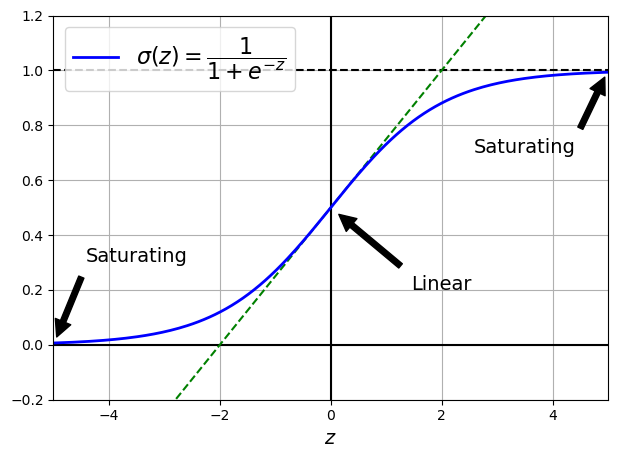

In [16]:
# Código extra – esta celda genera y guarda la Figura 11–1

import numpy as np

# Define la función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Genera 200 valores entre -5 y 5
z = np.linspace(-5, 5, 200)

# Línea horizontal en y = 0
plt.plot([-5, 5], [0, 0], 'k-')

# Línea horizontal en y = 1 (discontinua)
plt.plot([-5, 5], [1, 1], 'k--')

# Línea vertical en x = 0
plt.plot([0, 0], [-0.2, 1.2], 'k-')

# Línea discontinua de referencia (pendiente)
plt.plot([-5, 5], [-3/4, 7/4], 'g--')

# Gráfica de la función sigmoide
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")

# Propiedades de las flechas (anotaciones)
props = dict(facecolor='black', shrink=0.1)

# Anotación en la zona de saturación superior
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")

# Anotación en la zona de saturación inferior
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")

# Anotación en la región aproximadamente lineal
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")

# Activa la cuadrícula
plt.grid(True)

# Define los límites de los ejes
plt.axis([-5, 5, -0.2, 1.2])

# Etiqueta del eje X
plt.xlabel("$z$")

# Muestra la leyenda en la esquina superior izquierda
plt.legend(loc="upper left", fontsize=16)

# Guarda la figura con el nombre especificado
save_fig("sigmoid_saturation_plot")

# Muestra la gráfica en pantalla
plt.show()

## Gradientes explosivos (exploding gradients)


Sucede cuando los gradientes crecen demasiado.

¿Qué pasa?
- Los pesos cambian de forma muy brusca.
- El entrenamiento se vuelve inestable.
- Pueden aparecer valores NaN o pérdidas infinitas.

¿Por qué ocurre?
- Multiplicación repetida de valores mayores que 1.
- Mala inicialización de pesos.
- Redes muy profundas.


$2 \times 2 \times 2 \times \cdots \rightarrow \infty $


Importancia

Estos problemas dificultan el entrenamiento de redes profundas y fueron una limitación importante en los inicios del deep learning.


Soluciones comunes

- Usar funciones de activación como ReLU, Leaky ReLU o ELU.
- Inicialización adecuada de pesos (LeCun, Xavier/Glorot, He/Kaiming)
- Batch Normalization para estabilizar las activaciones.
- Gradient Clipping para evitar valores extremos.
- Arquitecturas avanzadas como ResNet o LSTM.


Idea clave

- Gradiente evanescente → la red no aprende.
- Gradiente explosivo → la red se vuelve inestable.

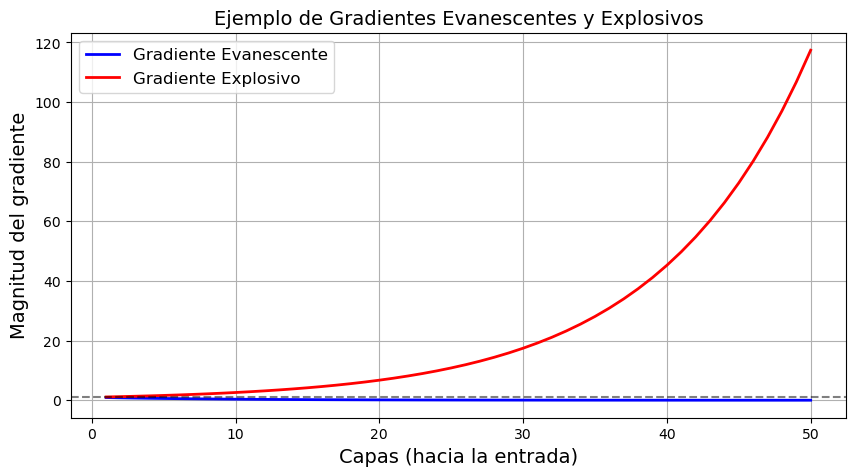

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Número de capas simuladas
num_layers = 50

# Gradientes simulados
grad_small = 0.9 * np.ones(num_layers)  # gradientes que disminuyen (evanescentes)
grad_large = 1.1 * np.ones(num_layers)  # gradientes que crecen (explosivos)

# Producto acumulativo para simular backpropagation
grad_vanish = np.cumprod(grad_small)
grad_explode = np.cumprod(grad_large)

# Plot
plt.figure(figsize=(10,5))
plt.plot(range(1, num_layers+1), grad_vanish, label='Gradiente Evanescente', color='blue', linewidth=2)
plt.plot(range(1, num_layers+1), grad_explode, label='Gradiente Explosivo', color='red', linewidth=2)
plt.axhline(1, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Capas (hacia la entrada)')
plt.ylabel('Magnitud del gradiente')
plt.title('Ejemplo de Gradientes Evanescentes y Explosivos')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

| Inicialización de pesos       | Funciones de activación                                     | Varianza de la distribución normal |
|-------------------------------|------------------------------------------------------------|----------------------------------|
| **LeCun**                     | SELU                                                       | $\sigma^2 = 1 / n_\text{inputs}$ |
| **Xavier / Glorot**           | Sigmoid, Tanh, Softmax, Lineal (ninguna)                  | $\sigma^2 = 2 / (n_\text{inputs} + n_\text{outputs})$ |
| **He / Kaiming**              | ReLU, Leaky ReLU, ELU, GELU, Swish, Mish                  | $\sigma^2 = 2 / n_\text{inputs}$ |}$ |{inputs}$ |

## Xavier and He Initialization

De manera predeterminada, <code> Keras </code> utiliza la inicialización **Glorot** con una distribución uniforme (Valores aleatorios)

In [25]:
# Crea una capa densa (fully connected) con 50 neuronas
# activation="relu": función de activación ReLU para las neuronas
# kernel_initializer="he_normal": inicialización He (Kaiming) normal,
#    recomendada para activaciones ReLU para mantener gradientes estables
dense = tf.keras.layers.Dense(50, activation="relu",
                              kernel_initializer="he_normal")

In [26]:
import tensorflow as tf

# Inicializador He promedio (fan_avg) con distribución uniforme
# - scale=2.0: factor de escala recomendado para activaciones ReLU
# - mode="fan_avg": usa promedio de fan_in y fan_out (He “promedio”)
# - distribution="uniform": los pesos se toman de una distribución uniforme
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg",
                                                    distribution="uniform")

# Crea una capa densa (fully connected) con 50 neuronas
# - activation="sigmoid": función sigmoide
# - kernel_initializer=he_avg_init: usa la inicialización definida arriba
dense = tf.keras.layers.Dense(50, activation="sigmoid",
                              kernel_initializer=he_avg_init)

## Funciones de activación no saturantes

### Leaky ReLU

**ReLU (Rectified Linear Unit)**

La función ReLU se define como:

$\text{ReLU}(z) = \max(0, z)$

- Si $z > 0$, la salida es $z$.  
- Si $z \le 0$, la salida es 0.  


Por qué ReLU es efectiva

- **Simplicidad computacional**: solo requiere comparar con 0.  
- **No satura para valores positivos**: los gradientes no se hacen pequeños como en <code> sigmoide </code> o <code> tanh </code>.  
- **Sparsity (activación escasa)**: muchas neuronas producen 0, lo que puede mejorar eficiencia y generalización.  


**Por qué ReLU no es perfecta: Neuronas moribundas (Dead Neurons)**

- Una neurona “muere” si siempre produce $0$.  
- Gradiente $= 0$ para entradas negativas → pesos no se actualizan → la neurona deja de aprender.  

Cómo sucede:

1. Pesos iniciales grandes o sesgados → neurona empieza en región negativa.  
2. Tasa de aprendizaje alta → pesos se actualizan demasiado y empujan neurona a región negativa permanente.  
3. Una vez allí → gradiente $= 0$ → neurona muere.  

Ejemplo intuitivo:

Supongamos $z = w \cdot x + b$:

- Si $z < 0$ para todas las entradas → salida $= 0$  
- Gradiente $\frac{\partial \text{ReLU}}{\partial z} = 0$ → pesos no se actualizan  
- La neurona queda muerta y no contribuye al aprendizaje  

Cómo mitigar el problema de neuronas moribundas

- **Leaky ReLU**: $\text{LeakyReLU}(z) = \max(\alpha z, z)$ con $\alpha \approx 0.01$ → gradiente pequeño para valores negativos.  
- **Parametric ReLU (PReLU)**: similar a Leaky ReLU, pero $\alpha$ se aprende durante entrenamiento.  
- **Inicialización He / Kaiming**: mantiene la varianza adecuada para que la mayoría de neuronas estén activas inicialmente.  
- **Tasa de aprendizaje moderada**: evita que neuronas entren permanentemente en la región negativa.  


Resumen clave

- ReLU es efectiva: simple y no satura en la parte positiva.  
- No es perfecta: algunas neuronas pueden morir si siempre reciben entradas negativas, sobre todo con pesos grandes o alta tasa de aprendizaje.  
- Soluciones: Leaky ReLU, PReLU, inicialización He, aprendizaje cuidadoso.

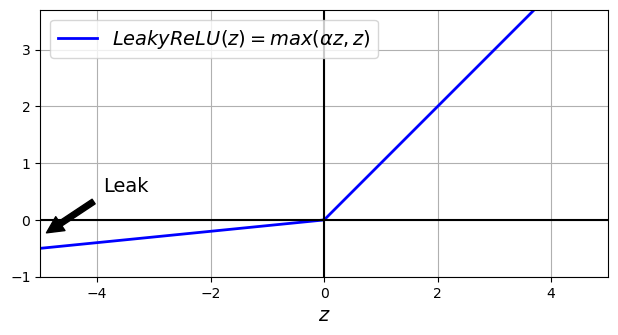

In [33]:
# extra code – this cell generates and saves Figure 11–2

def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

save_fig("leaky_relu_plot")
plt.show()

La función **Leaky ReLU** se define como:

$\text{LeakyReLU}(z) = \max(\alpha z, z)$

- Para $z > 0$, la salida es $z$ (igual que ReLU).  
- Para $z \le 0$, la salida es $\alpha z$ con $\alpha > 0$ (generalmente $\alpha \approx 0.01$).  


Qué hace $\alpha$

- Introduce una **pendiente pequeña para valores negativos**, en lugar de hacer la salida $0$ como en ReLU.  
- Esto permite que incluso si la entrada es negativa, la neurona **siga recibiendo gradiente** durante backpropagation:

$\frac{\partial \text{LeakyReLU}}{\partial z} = 
\begin{cases} 
1 & \text{si } z > 0 \\ 
\alpha & \text{si } z \le 0 
\end{cases}$

- Así, los pesos de la neurona **siguen actualizándose**, evitando que la neurona muera.  


Efecto práctico

- Con ReLU puro, una neurona en la región negativa siempre tiene gradiente $0$ → puede morir permanentemente.  
- Con Leaky ReLU, la pendiente $\alpha$ asegura que **aunque la neurona esté en valores negativos, sobrevive y sigue aprendiendo**.  
- Por eso se dice que $\alpha$ “salva” a las neuronas moribundas.  


Resumen clave

- $\alpha$ controla la pendiente en la región negativa de la activación.  
- Un $\alpha$ pequeño (0.01–0.1) es suficiente para mantener activas las neuronas negativas.  
- Previene el problema de **neuronas muertas**, especialmente en redes profundas o con tasas de aprendizaje altas.

In [35]:
# Crea una activación Leaky ReLU con pendiente alpha=0.2 para valores negativos
# Nota: el valor por defecto de alpha en Keras es 0.3
leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)

# Crea una capa densa (fully connected) con 50 neuronas
# - activation=leaky_relu: usa la activación Leaky ReLU definida arriba
# - kernel_initializer="he_normal": inicialización He (Kaiming) normal, recomendada para activaciones ReLU/Leaky ReLU
dense = tf.keras.layers.Dense(50, activation=leaky_relu,
                              kernel_initializer="he_normal")
dense

In [36]:
import tensorflow as tf

# Modelo secuencial de Keras
model = tf.keras.models.Sequential([
    # [...]  # otras capas pueden ir aquí

    # Capa densa con 50 neuronas
    # - kernel_initializer="he_normal": inicialización He (Kaiming) normal, recomendable para ReLU/Leaky ReLU
    # - sin activación aquí, se aplicará en la siguiente capa
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),

    # Capa de activación Leaky ReLU como capa separada
    # - alpha=0.2: pendiente pequeña para valores negativos, previniendo neuronas muertas
    tf.keras.layers.LeakyReLU(alpha=0.2),

    # [...]  # otras capas pueden ir aquí
])

#### PRelU

**PReLU (Parametric ReLU)**

La función PReLU es una extensión de Leaky ReLU, donde la pendiente para valores negativos no es fija, sino que se aprende durante el entrenamiento.

Se define como:

$\text{PReLU}(z) = \max(\alpha z, z)$

- Para $z > 0$, la salida es $z$.  
- Para $z \le 0$, la salida es $\alpha z$, pero $\alpha$ es un parámetro aprendido: la red ajusta automáticamente cuánto “leak” aplicar.  

Ventajas de PReLU

1. **Evita neuronas muertas**: igual que Leaky ReLU, siempre hay un gradiente en la región negativa.  
2. **Flexible**: como $\alpha$ se aprende, la red puede adaptarlo para cada neurona según la distribución de los datos.  
3. **Mejor desempeño**: a menudo mejora la convergencia y la precisión en redes profundas, comparado con ReLU o Leaky ReLU fijo.  

Cómo funciona el aprendizaje de $\alpha$

- Durante backpropagation, la derivada con respecto a $\alpha$ también se calcula:

$\frac{\partial \text{PReLU}(z)}{\partial \alpha} = 
\begin{cases} 
0 & \text{si } z > 0 \\ 
z & \text{si } z \le 0 
\end{cases}$

- Esto permite que el optimizador ajuste $\alpha$ automáticamente para minimizar la función de pérdida.  
r la función de pérdida.  

Resumen clave

- PReLU es Leaky ReLU con $\alpha$ aprendible.  
- Evita el problema de neuronas muertas y se adapta a cada neurona, mejorando el aprendizaje.  
- Muy útil en redes profundas donde la distribución de activaciones pueden variar mucho.

**NOTA:** PReLU suele superar ampliamente a ReLU en conjuntos de datos grandes de imágenes, pero en conjuntos más pequeños existe un mayor riesgo de sobreajuste al conjunto de entrenamiento.

### ELU

**ELU y SELU: Activaciones suaves frente a ReLU, Leaky ReLU y PReLU**

Funciones como ReLU, Leaky ReLU y PReLU cambian **drásticamente en $z=0$**:

- ReLU: $\text{ReLU}(z) = \max(0, z)$  
- Leaky ReLU: $\text{LeakyReLU}(z) = \max(\alpha z, z)$  
- PReLU: $\text{PReLU}(z) = \max(\alpha z, z)$ con $\alpha$ aprendido  

Estas funciones son **no suaves** en $z=0$ porque su derivada tiene un salto, lo que puede generar gradientes abruptos durante la optimización.


**Exponential Linear Unit (ELU)**

$\text{ELU}(z) = 
\begin{cases} 
z & \text{si } z > 0 \\ 
\alpha (\exp(z) - 1) & \text{si } z \le 0 
\end{cases}$

- Para $z>0$, ELU se comporta linealmente (como ReLU).  
- Para $z \le 0$, es **suave y negativa**, acercándose a $-\alpha$ asintóticamente.  
- Beneficio: **derivada continua en todo $z$**, evitando saltos de gradiente.  


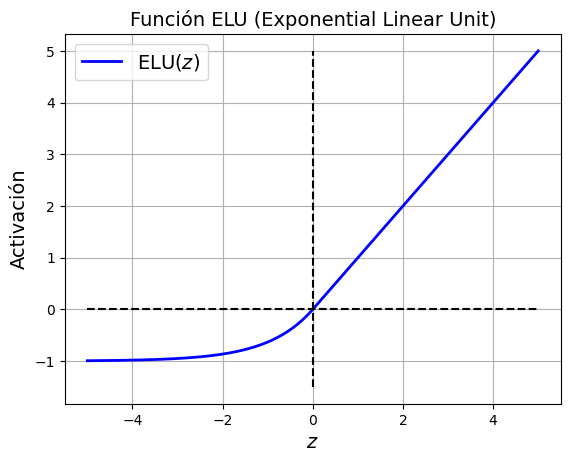

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de ELU
def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU($z$)")

# Opcionales: ejes y líneas de referencia
plt.plot([-5, 5], [0, 0], 'k--')  # eje horizontal
plt.plot([0, 0], [-1.5, 5], 'k--')  # eje vertical

# Anotaciones
plt.xlabel("$z$")
plt.ylabel("Activación")
plt.title("Función ELU (Exponential Linear Unit)")
plt.grid(True)
plt.legend()
plt.show()

Ventajas de ELU y SELU frente a ReLU, Leaky ReLU y PReLU

- Son **suaves en $z=0$**, derivadas continuas → gradientes más estables.  
- Evitan cambios abruptos que podrían afectar la propagación del gradiente.  
- SELU puede **auto-normalizar** activaciones en redes profundas.  

Resumen clave

- ReLU, Leaky ReLU y PReLU: activaciones rápidas, pero no suaves en $z=0$.  
- ELU y SELU: activaciones suaves, diferenciables y más estables en redes profundas.

In [45]:
# Crea una capa densa (fully connected) con 50 neuronas
# - activation="elu": usa la función de activación ELU (Exponential Linear Unit)
#   * Suave en todo z, evita cambios abruptos en z=0
# - kernel_initializer="he_normal": inicialización He (Kaiming) normal, recomendada para activaciones que crecen linealmente como ReLU o ELU
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

### SELU

**Scaled Exponential Linear Unit (SELU)**

$\text{SELU}(z) = \lambda 
\begin{cases} 
z & \text{si } z > 0 \\ 
\alpha (\exp(z) - 1) & \text{si } z \le 0 
\end{cases}$

- Similar a ELU pero con escala $\lambda$.  
- Propiedad especial: con **inicialización LeCun**, SELU tiende a **auto-normalizar** activaciones, manteniendo media ~0 y varianza ~1.  
- Esto facilita el entrenamiento de redes profundas sin necesidad de batch normalization.  


Cuando se dice que una red “se auto-normaliza” usando SELU, se refiere a que **si todas las capas ocultas usan SELU**, las activaciones tienden automáticamente a mantener:

- **Media cercana a 0**
- **Varianza cercana a 1**

sin necesidad de Batch Normalization.

**Condiciones necesarias para que la auto-normalización funcione:**

1. **Todas las capas ocultas deben usar SELU**  
   - Si mezclas SELU con ReLU, tanh u otras activaciones, la propiedad se pierde.

2. **Inicialización LeCun (normal o uniforme)**  
   - La inicialización debe mantener la varianza adecuada al inicio.
   - Por ejemplo: `tf.keras.initializers.lecun_normal()` o `lecun_uniform()`.

3. **Entradas estandarizadas**  
   - Características de entrada con media ~0 y varianza ~1.  
   - Esto asegura que la primera capa cumpla la condición de auto-normalización.

4. **Redes totalmente conectadas (MLP)**  
   - La garantía teórica de auto-normalización está comprobada solo para **perceptrones multicapa densos**.  
   - Con convoluciones, RNNs u otras arquitecturas, el comportamiento puede variar.

5. **Dropout compatible (Alpha Dropout)**  
   - Si se usa Dropout, debe ser **Alpha Dropout**, que preserva la media y varianza.  
   - Dropout estándar rompe la auto-normalización.

6. **Regularización (L1/L2) limitada**  
   - Penalizaciones muy fuertes sobre los pesos pueden alterar la varianza de las activaciones.  
   - SELU funciona mejor con **regularización ligera** o sin regularización pesada.


Por defecto, los hiperparámetros SELU (`scale` y `alpha`) se ajustan de tal manera que la salida media de cada neurona se mantiene cercana a 0 y la desviación estándar se mantiene cercana a 1 (suponiendo que las entradas también estén estandarizadas con media 0 y desviación estándar 1, y que se respeten otras restricciones, como se explica en el libro). Utilizando esta función de activación, incluso una red neuronal de 1000 capas mantiene aproximadamente una media de 0 y una desviación estándar de 1 en todas las capas, evitando el problema de los gradientes explosivos o evanescentes.

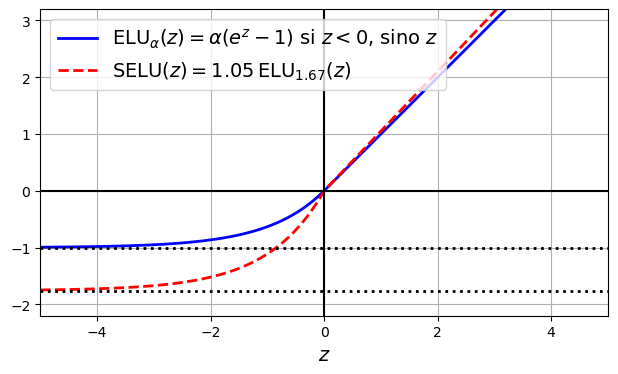

In [51]:
# extra code – this cell generates and saves Figure 11–3

from scipy.special import erfc
import numpy as np
import matplotlib.pyplot as plt

# Cálculo de alpha y scale para SELU
# Estos valores garantizan que las activaciones se auto-normalicen
# (media ~0 y desviación estándar ~1), según la ecuación 14 del paper original
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

# Definición de la función ELU
# - alpha controla la parte negativa
# - suave en todo z, evita saltos bruscos en z=0
def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

# Definición de la función SELU
# - scale y alpha están ajustados para auto-normalizar las activaciones
# - combina ELU con la constante de escala
def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

# Generamos el rango de valores de entrada
z = np.linspace(-5, 5, 200)

# Graficamos ELU
plt.plot(z, elu(z), "b-", linewidth=2,
         label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ si $z < 0$, sino $z$")

# Graficamos SELU
plt.plot(z, selu(z), "r--", linewidth=2,
         label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")

# Líneas de referencia
plt.plot([-5, 5], [0, 0], 'k-')         # eje horizontal
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)       # guía para ELU
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2) # guía para SELU
plt.plot([0, 0], [-2.2, 3.2], 'k-')     # eje vertical

plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

# Guardar la figura en la carpeta de imágenes
save_fig("elu_selu_plot")

# Mostrar la gráfica
plt.show()

Utilizar SELU es sencillo:

In [53]:
import tensorflow as tf

# Capa densa (fully connected) con 50 neuronas
# - activation="selu": usa la función SELU (Scaled Exponential Linear Unit)
#   * Suave en todo z, evita saltos bruscos en z=0
#   * Propiedad especial: si todas las capas ocultas usan SELU, tienden a auto-normalizarse (media ~0, varianza ~1)
# - kernel_initializer="lecun_normal": inicialización LeCun normal, recomendada para SELU
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

**Material adicional: un ejemplo de red autorregulada con SELU**

Vamos a crear una red neuronal para Fashion MNIST con 100 capas ocultas, utilizando la función de activación SELU:

In [55]:
import tensorflow as tf

# Fijar la semilla para reproducibilidad
tf.random.set_seed(42)

# Crear un modelo secuencial
model = tf.keras.Sequential()

# Capa de entrada: aplana imágenes 28x28 a un vector de 784 elementos
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))

# Capas ocultas profundas con SELU
# - 100 capas densas, cada una con 100 neuronas
# - activation="selu": activación SELU para auto-normalización
# - kernel_initializer="lecun_normal": inicialización LeCun recomendada para SELU
# Nota: con esta combinación, las activaciones tienden a mantenerse con media ~0 y varianza ~1 capa por capa
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))

# Capa de salida
# - 10 neuronas para clasificación (por ejemplo, dígitos 0-9)
# - activation="softmax" para obtener probabilidades
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [56]:
import tensorflow as tf

# Compila el modelo para entrenarlo
model.compile(
    # Función de pérdida para clasificación de enteros (etiquetas 0,1,...,9)
    loss="sparse_categorical_crossentropy",

    # Optimizador SGD (Stochastic Gradient Descent) con tasa de aprendizaje baja
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),

    # Métrica que se monitorea durante el entrenamiento
    metrics=["accuracy"]
)

In [57]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 100)               78500     
                                                                 
 dense_7 (Dense)             (None, 100)               10100     
                                                                 
 dense_8 (Dense)             (None, 100)               10100     
                                                                 
 dense_9 (Dense)             (None, 100)               10100     
                                                                 
 dense_10 (Dense)            (None, 100)               10100     
                                                                 
 dense_11 (Dense)            (None, 100)              

Ahora vamos a entrenarlo. No olvides escalar las entradas para que tengan una media de 0 y una desviación estándar de 1:

In [59]:
import tensorflow as tf

# Cargar el dataset Fashion MNIST (imágenes de 28x28 de ropa)
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

# Separar en entrenamiento y prueba
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

# Crear conjunto de entrenamiento y validación
# - Últimos 5000 ejemplos del entrenamiento completo se usan para validación
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

# Normalizar los datos de entrada a [0,1] dividiendo por 255
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [60]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [61]:
import numpy as np

# Calcular la media de cada píxel en el conjunto de entrenamiento
# axis=0 → se calcula por cada posición de píxel, no por imagen
# keepdims=True → mantiene la forma para poder restarla directamente
pixel_means = X_train.mean(axis=0, keepdims=True)

# Calcular la desviación estándar de cada píxel en el conjunto de entrenamiento
pixel_stds = X_train.std(axis=0, keepdims=True)

# Estandarizar el conjunto de entrenamiento
# - Restar la media y dividir por desviación estándar → media ~0, varianza ~1
X_train_scaled = (X_train - pixel_means) / pixel_stds

# Estandarizar el conjunto de validación usando media y std del entrenamiento
X_valid_scaled = (X_valid - pixel_means) / pixel_stds

# Estandarizar el conjunto de prueba usando media y std del entrenamiento
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [62]:
# Entrenar el modelo con los datos estandarizados
# - X_train_scaled, y_train: datos de entrenamiento
# - epochs=5: número de veces que recorrerá todo el conjunto de entrenamiento
# - validation_data=(X_valid_scaled, y_valid): conjunto de validación para monitorear sobreajuste
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=5,
    validation_data=(X_valid_scaled, y_valid)
)

Epoch 1/5


1719/1719 [==============================] - 58s 28ms/step - loss: 1.0343 - accuracy: 0.6183 - val_loss: 0.7902 - val_accuracy: 0.7256
Epoch 2/5
1719/1719 [==============================] - 46s 27ms/step - loss: 0.7352 - accuracy: 0.7422 - val_loss: 0.6424 - val_accuracy: 0.7794
Epoch 3/5
1719/1719 [==============================] - 44s 26ms/step - loss: 0.6418 - accuracy: 0.7756 - val_loss: 0.5751 - val_accuracy: 0.7940
Epoch 4/5
1719/1719 [==============================] - 45s 26ms/step - loss: 0.5644 - accuracy: 0.7987 - val_loss: 0.5143 - val_accuracy: 0.8218
Epoch 5/5
1719/1719 [==============================] - 44s 26ms/step - loss: 0.5172 - accuracy: 0.8153 - val_loss: 0.4984 - val_accuracy: 0.8230


La red logró aprender, a pesar de su profundidad. Ahora veamos qué sucede si intentamos usar la función de activación ReLU en su lugar:

In [64]:
import tensorflow as tf

# Fijar la semilla aleatoria para TensorFlow
# Esto asegura que la inicialización de pesos y el entrenamiento sean reproducibles
tf.random.set_seed(42)

In [65]:
import tensorflow as tf

# Crear un modelo secuencial
model = tf.keras.Sequential()

# Capa de entrada: aplana imágenes 28x28 a un vector de 784 elementos
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))

# Capas ocultas profundas con ReLU
# - 100 capas densas, cada una con 100 neuronas
# - activation="relu": activación ReLU
#   * Rápida y eficiente, pero puede sufrir el problema de neuronas moribundas
# - kernel_initializer="he_normal": inicialización He (Kaiming) normal
#   * Recomendado para ReLU para mantener la varianza de activaciones estable
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))

# Capa de salida
# - 10 neuronas para clasificación (por ejemplo, dígitos 0-9)
# - activation="softmax" convierte las salidas en probabilidades
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [66]:
import tensorflow as tf

# Compilar el modelo para entrenamiento
model.compile(
    # Función de pérdida para clasificación con etiquetas enteras (0,1,...,9)
    loss="sparse_categorical_crossentropy",

    # Optimizador SGD (Stochastic Gradient Descent) con tasa de aprendizaje baja
    # - La tasa baja ayuda a evitar que algunas neuronas ReLU mueran por pasos demasiado grandes
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),

    # Métricas que se monitorean durante el entrenamiento
    metrics=["accuracy"]
)

In [67]:
# Entrenar el modelo con los datos estandarizados
# - X_train_scaled, y_train: datos de entrenamiento
# - epochs=5: número de veces que el modelo recorre todo el conjunto de entrenamiento
# - validation_data=(X_valid_scaled, y_valid): conjunto de validación para monitorear sobreajuste
# Nota: con ReLU, algunas neuronas podrían morir si la tasa de aprendizaje es alta
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=5,
    validation_data=(X_valid_scaled, y_valid)
)

Epoch 1/5
1719/1719 [==============================] - 54s 25ms/step - loss: 2.1235 - accuracy: 0.1935 - val_loss: 1.8747 - val_accuracy: 0.3006
Epoch 2/5
1719/1719 [==============================] - 42s 24ms/step - loss: 1.7815 - accuracy: 0.3512 - val_loss: 1.9135 - val_accuracy: 0.2148
Epoch 3/5
1719/1719 [==============================] - 41s 24ms/step - loss: 1.6603 - accuracy: 0.3448 - val_loss: 1.2855 - val_accuracy: 0.4894
Epoch 4/5
1719/1719 [==============================] - 42s 25ms/step - loss: 1.2216 - accuracy: 0.5109 - val_loss: 2.6751 - val_accuracy: 0.0980
Epoch 5/5
1719/1719 [==============================] - 40s 23ms/step - loss: 1.3609 - accuracy: 0.4340 - val_loss: 0.9898 - val_accuracy: 0.5854


No fue nada bueno, sufrimos el problema de los gradientes que se desvanecían o explotaban.

### GELU, Swish and Mish

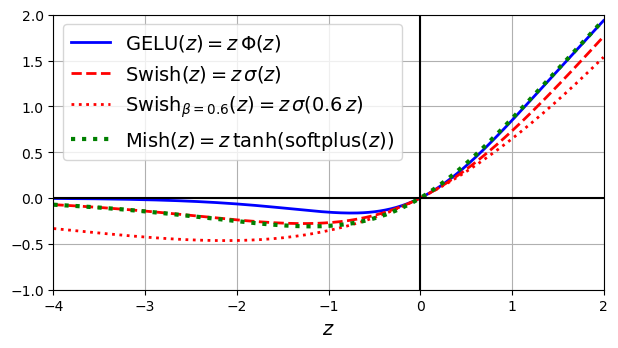

In [70]:
# Extra code – esta celda genera y guarda la Figura 11–4

import numpy as np
import matplotlib.pyplot as plt

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Swish: función de activación suave
# - z * sigmoid(beta * z)
# - beta controla la pendiente en valores negativos
def swish(z, beta=1):
    return z * sigmoid(beta * z)

# GELU aproximada usando Swish
# - Beta = 1.702 para aproximar la integral de Gauss
def approx_gelu(z):
    return swish(z, beta=1.702)

# Softplus: función suave similar a ReLU
def softplus(z):
    return np.log(1 + np.exp(z))

# Mish: función suave que combina z y tanh(softplus(z))
# - Suaviza las transiciones y evita saturaciones fuertes
def mish(z):
    return z * np.tanh(softplus(z))

# Vector de valores de entrada para graficar
z = np.linspace(-4, 2, 200)

# Beta personalizado para Swish
beta = 0.6

# Graficar GELU aproximada
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")

# Graficar Swish beta=1
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")

# Graficar Swish con beta=0.6
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")

# Graficar Mish
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")

# Líneas de referencia
plt.plot([-4, 2], [0, 0], 'k-')  # eje x
plt.plot([0, 0], [-2.2, 3.2], 'k-')  # eje y

# Configuración de la cuadrícula y el aspecto
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

# Guardar la figura usando la función definida anteriormente
save_fig("gelu_swish_mish_plot")

# Mostrar la gráfica
plt.show()

# Batch Normalization

Batch Normalization es una técnica para **normalizar las activaciones** de cada mini-batch durante el entrenamiento, con el objetivo de **acelerar el aprendizaje y estabilizar redes profundas**.


**Algoritmo de Batch Normalization (4 pasos)**

Para cada mini-batch de activaciones $X = \{x_1, x_2, ..., x_m\}$:

1. **Calcular la media del batch**  
   $$\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i$$

2. **Calcular la varianza del batch**  
   $$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2$$

3. **Normalizar las activaciones**  
   $$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
   donde $\epsilon$ es un valor muy pequeño para evitar división por cero.

4. **Escalar y desplazar (parámetros aprendibles)**  
   $$y_i = \gamma \hat{x}_i + \beta$$
   - $\gamma$ ajusta la **escala**  
   - $\beta$ ajusta el **desplazamiento**  
   - Estos parámetros permiten que la red recupere representaciones originales si es necesario.

Batch Normalization: explicación de cada símbolo

Para cada mini-batch de activaciones $X = \{x_1, x_2, ..., x_m\}$:

1. **$\mathbf{x_i}$**  
   - Activación de la neurona correspondiente al **i-ésimo ejemplo del batch**.  
   - Antes de la normalización.

2. **$m$**  
   - Número de ejemplos en el mini-batch.  
   - Se usa para calcular la media y la varianza del batch.

3. **$\mu_B$**  
   - Media de las activaciones en el batch:  
     $$\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i$$  
   - Indica dónde se centra el batch en promedio.

4. **$\sigma_B^2$**  
   - Varianza de las activaciones en el batch:  
     $$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2$$  
   - Mide la dispersión de las activaciones alrededor de la media.

5. **$\epsilon$**  
   - Pequeño valor positivo para evitar división por cero al normalizar.  
   - Normalmente muy pequeño, por ejemplo $10^{-7}$.
   - Se comoce somo *término de suavizado*.

6. **$\hat{x}_i$**  
   - Activación normalizada:  
     $$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$  
   - Ahora tiene **media cercana a 0 y varianza cercana a 1** dentro del batch.

7. **$\gamma$ y $\beta$**  
   - Parámetros aprendibles por la red:  
     - $\gamma$ ajusta la **escala** de la activación.  
     - $\beta$ ajusta el **desplazamiento** (media).  
   - Permiten a la red **recuperar representaciones originales** si es necesario.

8. **$y_i$**  
   - Salida final de la normalización:  
     $$y_i = \gamma \hat{x}_i + \beta$$  
   - Esta activación se envía a la siguiente capa de la red.

**Ventajas de Batch Normalization:**

- **Reducción de covariate shift interno**: cada capa recibe activaciones con media y varianza más estables.
- **Permite tasas de aprendizaje más altas**: reduce riesgo de gradientes explosivos o desvanecientes.
- **Regularización ligera**: actúa parcialmente como Dropout, disminuyendo algo de sobreajuste.
- **Entrenamiento más rápido**: convergencia más rápida en redes profundas.


**Ventajas de Batch Normalization:**

- **Reducción de covariate shift interno**: cada capa recibe activaciones con media y varianza más estables.
- **Permite tasas de aprendizaje más altas**: reduce riesgo de gradientes explosivos o desvanecientes.
- **Regularización ligera**: actúa parcialmente como Dropout, disminuyendo algo de sobreajuste.
- **Entrenamiento más rápido**: convergencia más rápida en redes profundas.


**Limitaciones y consideraciones:**

- El comportamiento depende del **tamaño del batch**: batches muy pequeños pueden producir estadísticas poco fiables.
- Introduce **dependencia entre ejemplos del batch**, lo que puede afectar inferencia si no se usan estadísticas acumuladas.
- Para **redes recurrentes** o secuencias, BN es menos directo de aplicar; en esos casos se prefieren Layer Normalization o Weight Normalization.


 Nota:

Batch Normalization se puede usar con cualquier activación (ReLU, ELU, GELU, etc.) y es especialmente útil cuando **no se usa SELU**, ya que SELU tiene su propia auto-normalización.

In [79]:
# Extra code – limpiar contadores de nombres de capas y reiniciar la sesión de Keras
# Esto es útil para evitar conflictos de nombres si se crean múltiples modelos en la misma sesión
tf.keras.backend.clear_session()

# Establecer la semilla aleatoria de TensorFlow para reproducibilidad
# Asegura que los pesos iniciales y cualquier operación aleatoria sean iguales cada vez que corras el código
tf.random.set_seed(42)

In [80]:
# Modelo secuencial con Batch Normalization

model = tf.keras.Sequential([
    
    # Aplanar la imagen de 28x28 píxeles a un vector de 784 elementos (0)
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    
    # Normalización del batch antes de la primera capa densa
    # Esto ayuda a estabilizar las activaciones y acelera el entrenamiento (1)
    tf.keras.layers.BatchNormalization(),
    
    # Primera capa densa con 300 neuronas, activación ReLU y inicialización He (2)
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    
    # Normalización del batch después de la primera capa densa
    # Reduce covariate shift interno y mejora la convergencia (3)
    tf.keras.layers.BatchNormalization(),
    
    # Segunda capa densa con 100 neuronas, activación ReLU y inicialización He (4)
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    
    # Normalización del batch después de la segunda capa densa (5)
    tf.keras.layers.BatchNormalization(),
    
    # Capa de salida con 10 neuronas y activación softmax para clasificación multiclase (6)
    tf.keras.layers.Dense(10, activation="softmax")
])

In [81]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 batch_normalization (Batch  (None, 784)               3136      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 batch_normalization_1 (Bat  (None, 300)               1200      
 chNormalization)                                                
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 batch_normalization_2 (Bat  (None, 100)               4

In [82]:
model.layers[1]

In [83]:
# Lista las variables de la primera capa de Batch Normalization del modelo
# Para cada variable devuelve una tupla: (nombre de la variable, si es entrenable o no)
# Normalmente devuelve:
# - gamma: parámetro de escala aprendible (trainable=True)
# - beta: parámetro de desplazamiento aprendible (trainable=True)
# - moving_mean: media móvil del batch (trainable=False)
# - moving_variance: varianza móvil del batch (trainable=False)
[(var.name, var.trainable) for var in model.layers[1].variables]

[('batch_normalization/gamma:0', True),
 ('batch_normalization/beta:0', True),
 ('batch_normalization/moving_mean:0', False),
 ('batch_normalization/moving_variance:0', False)]

In [84]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))


Epoch 1/2
1719/1719 [==============================] - 14s 7ms/step - loss: 0.5527 - accuracy: 0.8081 - val_loss: 0.4019 - val_accuracy: 0.8514
Epoch 2/2
1719/1719 [==============================] - 12s 7ms/step - loss: 0.4055 - accuracy: 0.8551 - val_loss: 0.3649 - val_accuracy: 0.8636


A veces, aplicar BN antes de la función de activación funciona mejor (existe un debate sobre este tema). Además, la capa anterior a una capa de `BatchNormalization` no necesita tener términos de sesgo, ya que la capa de `BatchNormalization` también los tiene; sería un desperdicio de parámetros, por lo que puede establecer `use_bias=False` al crear esas capas:

In [86]:
# Limpia el estado global de Keras
# Esto reinicia los contadores de nombres de capas/modelos
# y libera recursos, útil cuando ejecutas varias veces el código
tf.keras.backend.clear_session()

# Fija la semilla aleatoria para TensorFlow
# Esto hace que los resultados sean reproducibles (mismos pesos iniciales, etc.)
tf.random.set_seed(42)

In [87]:
# Se define un modelo secuencial (capas una tras otra)
model = tf.keras.Sequential([
    
    # Aplana la imagen de entrada de 28x28 a un vector de 784 valores
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    
    # Capa densa con 300 neuronas
    # kernel_initializer="he_normal": inicialización adecuada para ReLU
    # use_bias=False: no se usa sesgo porque BatchNorm lo compensa
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    
    # Normaliza las activaciones para estabilizar y acelerar el entrenamiento
    tf.keras.layers.BatchNormalization(),
    
    # Función de activación ReLU (introduce no linealidad)
    tf.keras.layers.Activation("relu"),
    
    # Segunda capa densa con 100 neuronas
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    
    # Nuevamente se aplica Batch Normalization
    tf.keras.layers.BatchNormalization(),
    
    # Activación ReLU
    tf.keras.layers.Activation("relu"),
    
    # Capa de salida con 10 neuronas (una por clase)
    # softmax convierte las salidas en probabilidades
    tf.keras.layers.Dense(10, activation="softmax")
])

In [88]:
# Compila el modelo definiendo cómo va a aprender
# loss: función de pérdida para clasificación multiclase con etiquetas enteras
# optimizer: SGD (descenso de gradiente estocástico) ajusta los pesos
# metrics: accuracy mide qué tan bien clasifica el modelo
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

# Entrena el modelo
# X_train, y_train: datos y etiquetas de entrenamiento
# epochs=2: el modelo recorre el dataset completo 2 veces
# validation_data: conjunto de validación para evaluar desempeño durante el entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=2,
    validation_data=(X_valid, y_valid)
)

Epoch 1/2
1719/1719 [==============================] - 13s 7ms/step - loss: 0.6059 - accuracy: 0.7990 - val_loss: 0.4388 - val_accuracy: 0.8424
Epoch 2/2
1719/1719 [==============================] - 12s 7ms/step - loss: 0.4294 - accuracy: 0.8498 - val_loss: 0.3860 - val_accuracy: 0.8638


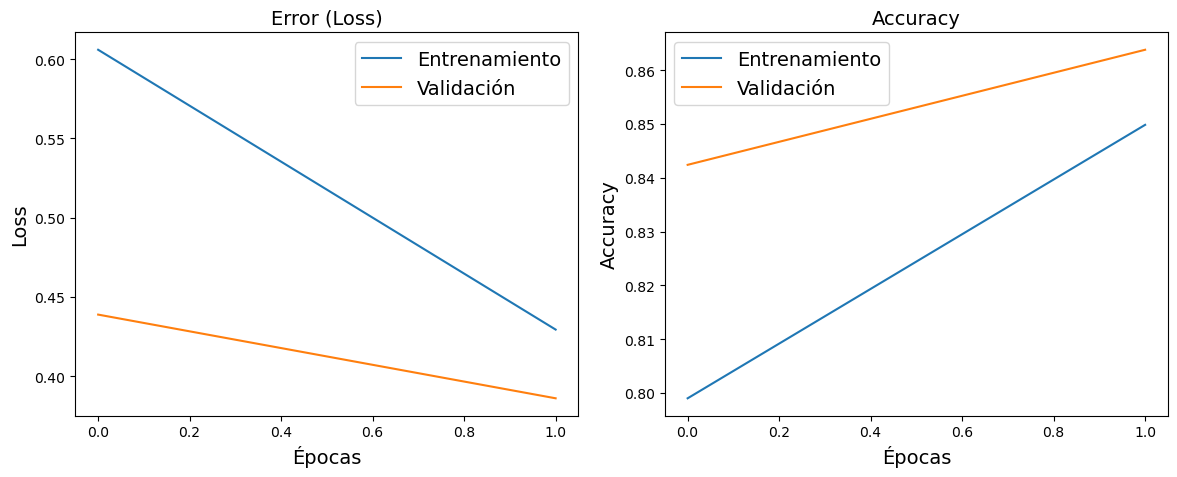

In [89]:
# Extraer métricas del historial
loss = history.history["loss"]                 # Error en entrenamiento
val_loss = history.history["val_loss"]         # Error en validación
accuracy = history.history["accuracy"]         # Precisión en entrenamiento
val_accuracy = history.history["val_accuracy"] # Precisión en validación

# Crear una figura con tamaño personalizado
plt.figure(figsize=(12, 5))

# ===== GRÁFICA DE ERROR (LOSS) =====
plt.subplot(1, 2, 1)  # 1 fila, 2 columnas, posición 1

# Graficar error de entrenamiento
plt.plot(loss, label="Entrenamiento")

# Graficar error de validación
plt.plot(val_loss, label="Validación")

# Títulos y etiquetas
plt.title("Error (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")

# Mostrar leyenda
plt.legend()

# ===== GRÁFICA DE ACCURACY =====
plt.subplot(1, 2, 2)  # 1 fila, 2 columnas, posición 2

# Graficar accuracy de entrenamiento
plt.plot(accuracy, label="Entrenamiento")

# Graficar accuracy de validación
plt.plot(val_accuracy, label="Validación")

# Títulos y etiquetas
plt.title("Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")

# Mostrar leyenda
plt.legend()

# Ajustar espacios para que no se encimen las gráficas
plt.tight_layout()

# Mostrar ambas gráficas
plt.show()

La **normalización por lotes (Batch Normalization)** se ha consolidado como una de las técnicas más importantes en el entrenamiento de redes neuronales profundas, ya que mejora la estabilidad, acelera la convergencia y permite usar tasas de aprendizaje más altas. Por ello, se ha convertido en una capa fundamental, especialmente en las **redes neuronales convolucionales profundas**, donde contribuye significativamente a mejorar el rendimiento y la generalización del modelo.


## Gradient Clipping

Todos los optimizadores `tf.keras.optimizers` aceptan los argumentos `clipnorm` o `clipvalue`:


In [93]:
# Se define el optimizador SGD (descenso de gradiente estocástico)
# clipvalue=1.0: limita (recorta) el valor de los gradientes
# Esto evita que los gradientes sean demasiado grandes (gradient exploding)
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)

# Se compila el modelo
# loss: función de pérdida para clasificación multiclase con etiquetas enteras
# optimizer: el optimizador definido anteriormente con gradient clipping
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer
)

In [94]:
# Se define el optimizador SGD
# clipnorm=1.0: limita la norma (magnitud total) del gradiente
# Esto evita que el gradiente crezca demasiado (exploding gradients)
optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)

# Se compila el modelo
# loss: función de pérdida para clasificación multiclase con etiquetas enteras
# optimizer: optimizador con gradient clipping por norma
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer
)


Ejemplo: supongamos que tenemos un gradiente

$g=[0.9, 100]$


**1. clipvalue = 1.0 (recorte por valor)**

Esto limita cada componente individual del vector al rango [-1, 1].

- 0.9 → se queda igual (está dentro del rango)  
- 100 → se recorta a 1  

Resultado:


$g=[0.9, 1]$

**2. clipnorm = 1.0 (recorte por norma)**

Esto escala **todo el vector** si su magnitud es mayor a 1, usando la **norma L2** (también llamada magnitud euclidiana):

La norma L2 del vector es:

$$
||g||_2 = \sqrt{0.9^2 + 100^2} \approx 100
$$

Si $||g||_2 > 1$, se **normaliza** el vector dividiéndolo por su norma y multiplicando por el límite (1 en este caso):

$$g_{\text{nuevo}} = \frac{g}{||g||_2} \cdot 1$$

**Nota:**<code> clipnorm=1.0 </code> Esto recortará el gradiente si la norma $l_2$ es mayor que el umbral que eligió, en este caso $1$

Resultado aproximado:

$g = [0.0089996,0.9999596]$

## Reutilización de capas preentrenadas

**Aprendizaje por transferencia en redes neuronales**

**Qué es el aprendizaje por transferencia**
El aprendizaje por transferencia es una técnica donde una red neuronal previamente entrenada en una tarea se reutiliza o adapta para realizar otra tarea relacionada. La red transfiere conocimiento de un dominio a otro.
Es útil cuando no se tiene suficiente data para entrenar desde cero o cuando se quiere acelerar el entrenamiento.

**Cómo funciona**

**1. Pre-entrenamiento**
Se toma una red grande entrenada en un conjunto de datos masivo. La red aprende características generales como bordes, texturas o formas.

**2. Transferencia de conocimiento**

* Se congelan las primeras capas de la red, que aprenden características generales.
* Se reemplazan o reestructuran las capas finales, que son específicas de la tarea original.

**3. Fine-tuning (ajuste fino)**
Se entrena la red en la nueva tarea usando tu dataset específico, ajustando preferentemente las capas finales. Si el dataset es grande, se pueden ajustar todas las capas.

**Tipos de transferencia**

**Feature extraction**
Solo se usan las capas iniciales como extractor de características y se entrena un clasificador nuevo encima. Ideal cuando el dataset nuevo es pequeño.

**Fine-tuning completo**
Se ajustan tanto las capas iniciales como las finales. Mejor cuando se tiene un dataset medianamente grande y se quiere adaptar todo el modelo.

**Ventajas**

* Reduce el tiempo de entrenamiento.
* Requiere menos datos para obtener buenos resultados.
* Permite aprovechar modelos entrenados en datasets muy grandes.
* Mejora el desempeño en tareas relacionadas cuando los datos son limitados.


**Ejemplos prácticos**

* Visión por computadora: usar ResNet entrenada en ImageNet para clasificar radiografías.
* Procesamiento de lenguaje natural: usar BERT o GPT entrenados en millones de textos para análisis de sentimientos o traducción.
* Reconocimiento de voz: adaptar modelos grandes entrenados en idiomas generales para un dialecto específico.

**Notas técnicas**

En términos matemáticos, si $f_{\theta}$ es el modelo preentrenado con parámetros $\theta$, y $D_{new}$ es el nuevo dataset, se puede:

* Usar $f_{\theta}$ como extractor de características:
  $$
  h = f_{\theta}^{\text{congelado}}(x), \quad y = g(h)
  $$
  donde $g$ es un clasificador nuevo.

* Ajustar todos los parámetros (fine-tuning):
  $$
  \theta' = \arg\min_{\theta} \mathcal{L}(f_\theta(x), y)
  $$
  donde $\mathcal{L}$ es la función de pérdida sobre el nuevo dataset.

**Nota sobre redes convolucionales.**

En redes convolucionales, para que el aprendizaje por transferencia funcione correctamente, las imágenes de entrada deben tener el mismo tamaño que las que fueron usadas para entrenar el modelo original. Por ejemplo, si se usa ResNet entrenada con imágenes $224 \times 224$, las imágenes nuevas también deben tener ese tamaño.

### Reutilización de un modelo de Keras

Dividiremos el conjunto de entrenamiento MNIST de moda en dos:
* `X_train_A`: todas las imágenes de todos los artículos, excepto camisetas/blusas y suéteres (clases 0 y 2).

* `X_train_B`: un conjunto de entrenamiento mucho más pequeño, con solo las primeras 200 imágenes de camisetas/blusas y suéteres.

Los conjuntos de validación y prueba también se dividen de esta manera, pero sin restringir el número de imágenes.

Entrenaremos un modelo con el conjunto A (tarea de clasificación con 8 clases) e intentaremos reutilizarlo para abordar el conjunto B (clasificación binaria). Esperamos transferir algo de conocimiento de la tarea A a la tarea B, ya que las clases del conjunto A (pantalones, vestidos, abrigos, sandalias, camisas, zapatillas, bolsos y botines) son algo similares a las clases del conjunto B (camisetas/blusas y suéteres). Sin embargo, dado que estamos utilizando capas `Dense`, solo se pueden reutilizar los patrones que aparecen en la misma ubicación (en cambio, las capas convolucionales se transferirán mucho mejor, ya que los patrones aprendidos se pueden detectar en cualquier parte de la imagen, como veremos en el capítulo 14).

In [104]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
# model A to "my_model_A".

# Definir IDs de las clases positivas y negativas para la tarea B
pos_class_id = class_names.index("Pullover")      # clase positiva para B
neg_class_id = class_names.index("T-shirt/top")  # clase negativa para B

# Función para dividir el dataset en tareas A y B
def split_dataset(X, y):
    # Identificar los ejemplos que irán a la tarea B
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    
    # Para la tarea A, eliminar las clases de B
    y_A = y[~y_for_B]
    
    # Para la tarea B, convertir a binario: 1 si Pullover, 0 si T-shirt/top
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    
    # Reordenar IDs de clases para la tarea A (ahora 8 clases)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reordenar IDs
    
    # Devolver tuplas: ((X_A, y_A), (X_B, y_B))
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

# Dividir datasets de entrenamiento, validación y test en tareas A y B
(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)

# Reducir la tarea B a solo 200 ejemplos de entrenamiento
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

# Fijar semilla para reproducibilidad
tf.random.set_seed(42)

# Construir el modelo A para la tarea de 8 clases (tarea A)
model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # aplanar imágenes 28x28
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),  # capa oculta 1
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),  # capa oculta 2
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),  # capa oculta 3
    tf.keras.layers.Dense(8, activation="softmax")  # salida 8 clases
])

# Compilar el modelo con pérdida de entropía cruzada y optimizador SGD
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

# Entrenar el modelo en la tarea A
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))

# Guardar el modelo entrenado para futuras transferencias
model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 [==============================] - 7s 4ms/step - loss: 1.1821 - accuracy: 0.6477 - val_loss: 0.7064 - val_accuracy: 0.7719
Epoch 2/20
1376/1376 [==============================] - 5s 4ms/step - loss: 0.6091 - accuracy: 0.8086 - val_loss: 0.5246 - val_accuracy: 0.8295
Epoch 3/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.4937 - accuracy: 0.8452 - val_loss: 0.4516 - val_accuracy: 0.8511
Epoch 4/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.4335 - accuracy: 0.8614 - val_loss: 0.4054 - val_accuracy: 0.8704
Epoch 5/20
1376/1376 [==============================] - 6s 4ms/step - loss: 0.3943 - accuracy: 0.8701 - val_loss: 0.3760 - val_accuracy: 0.8742
Epoch 6/20
1376/1376 [==============================] - 6s 5ms/step - loss: 0.3670 - accuracy: 0.8773 - val_loss: 0.3545 - val_accuracy: 0.8784
Epoch 7/20
1376/1376 [==============================] - 6s 5ms/step - loss: 0.3470 - accuracy: 0.8832 - val_loss: 0.3390 - val_accuracy:

In [105]:
# extra code – train and evaluate model B, without reusing model A

# Fijar semilla para reproducibilidad
tf.random.set_seed(42)

# Construir un nuevo modelo B para la tarea binaria (Pullover vs T-shirt/top)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # aplanar imágenes 28x28
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),  # capa oculta 1
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),  # capa oculta 2
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),  # capa oculta 3
    tf.keras.layers.Dense(1, activation="sigmoid")  # salida binaria
])

# Compilar el modelo con pérdida binaria y optimizador SGD
model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

# Entrenar el modelo B en el dataset pequeño (200 ejemplos)
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))

# Evaluar el desempeño del modelo B en el conjunto de prueba
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 [==============================] - 1s 86ms/step - loss: 0.7294 - accuracy: 0.3600 - val_loss: 0.7058 - val_accuracy: 0.4916
Epoch 2/20
7/7 [==============================] - 0s 40ms/step - loss: 0.6984 - accuracy: 0.4950 - val_loss: 0.6803 - val_accuracy: 0.6073
Epoch 3/20
7/7 [==============================] - 0s 40ms/step - loss: 0.6719 - accuracy: 0.6000 - val_loss: 0.6577 - val_accuracy: 0.6954
Epoch 4/20
7/7 [==============================] - 0s 27ms/step - loss: 0.6466 - accuracy: 0.6800 - val_loss: 0.6379 - val_accuracy: 0.7507
Epoch 5/20
7/7 [==============================] - 0s 39ms/step - loss: 0.6257 - accuracy: 0.7300 - val_loss: 0.6184 - val_accuracy: 0.7972
Epoch 6/20
7/7 [==============================] - 0s 43ms/step - loss: 0.6051 - accuracy: 0.7850 - val_loss: 0.6008 - val_accuracy: 0.8239
Epoch 7/20
7/7 [==============================] - 0s 42ms/step - loss: 0.5861 - accuracy: 0.8200 - val_loss: 0.5839 - val_accuracy: 0.8556
Epoch 8/20
7/7 [===========

[0.45477038621902466, 0.9089999794960022]

El modelo B alcanza una precisión del 91,85% en el conjunto de prueba. Ahora intentemos reutilizar el modelo preentrenado A.

In [107]:
# Cargar el modelo A previamente entrenado
model_A = tf.keras.models.load_model("my_model_A.keras")

# Crear un nuevo modelo para la tarea B reutilizando las capas de A, excepto la última
# model_A.layers[:-1] toma todas las capas de A menos la capa de salida de 8 clases
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])

# Añadir una nueva capa de salida para la tarea binaria (Pullover vs T-shirt/top)
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

Tenga en cuenta que `model_B_on_A` y `model_A` ahora comparten capas, por lo que cuando entrenamos uno, se actualizarán ambos modelos. Si queremos evitar eso, necesitamos construir `model_B_on_A` sobre un *clon* de `model_A`:

In [109]:
tf.random.set_seed(42)  # extra code – ensure reproducibility

In [110]:
# Clonar la arquitectura de model_A sin copiar los pesos
model_A_clone = tf.keras.models.clone_model(model_A)

# Copiar los pesos de model_A al clon para que ambos modelos tengan los mismos valores
model_A_clone.set_weights(model_A.get_weights())

In [111]:
# extra code – creating model_B_on_A just like in the previous cell

# Reutilizar todas las capas de model_A_clone excepto la última
# Esto conserva las características aprendidas en la tarea A
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])

# Añadir una nueva capa de salida para la tarea binaria (Pullover vs T-shirt/top)
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [112]:
# Congelar todas las capas heredadas de model_A (todas menos la última)
# Esto evita que se actualicen los pesos preentrenados durante el entrenamiento de la tarea B
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

# Crear el optimizador
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

# Compilar el modelo para la tarea binaria usando pérdida binaria y el optimizador definido
# Se mide la precisión como métrica
model_B_on_A.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [113]:
# Fase 1: entrenar solo la nueva capa de salida
# Las capas heredadas de model_A están congeladas
history = model_B_on_A.fit(
    X_train_B, y_train_B, 
    epochs=4, 
    validation_data=(X_valid_B, y_valid_B)
)

# Fase 2: descongelar todas las capas para fine-tuning
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True  # ahora todas las capas se actualizarán

# Recompilar el modelo después de cambiar la propiedad trainable
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(
    loss="binary_crossentropy", 
    optimizer=optimizer,
    metrics=["accuracy"]
)

# Continuar entrenamiento con fine-tuning de todas las capas
history = model_B_on_A.fit(
    X_train_B, y_train_B, 
    epochs=16, 
    validation_data=(X_valid_B, y_valid_B)
)

Epoch 1/4
7/7 [==============================] - 1s 86ms/step - loss: 0.7374 - accuracy: 0.4500 - val_loss: 0.7543 - val_accuracy: 0.4332
Epoch 2/4
7/7 [==============================] - 0s 42ms/step - loss: 0.7187 - accuracy: 0.4950 - val_loss: 0.7343 - val_accuracy: 0.4669
Epoch 3/4
7/7 [==============================] - 0s 40ms/step - loss: 0.6989 - accuracy: 0.5150 - val_loss: 0.7201 - val_accuracy: 0.4748
Epoch 4/4
7/7 [==============================] - 0s 39ms/step - loss: 0.6747 - accuracy: 0.5550 - val_loss: 0.7004 - val_accuracy: 0.5242
Epoch 1/16
7/7 [==============================] - 1s 72ms/step - loss: 0.6292 - accuracy: 0.6250 - val_loss: 0.6200 - val_accuracy: 0.6637
Epoch 2/16
7/7 [==============================] - 0s 42ms/step - loss: 0.5529 - accuracy: 0.7800 - val_loss: 0.5443 - val_accuracy: 0.7982
Epoch 3/16
7/7 [==============================] - 0s 29ms/step - loss: 0.4848 - accuracy: 0.8700 - val_loss: 0.4977 - val_accuracy: 0.8457
Epoch 4/16
7/7 [===============

Entonces, ¿cuál es el veredicto final?

In [115]:
# Evaluar el desempeño del modelo B entrenado sobre el conjunto de prueba
# Esto devuelve la pérdida (loss) y la precisión (accuracy) en X_test_B
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 [==============================] - 0s 3ms/step - loss: 0.2643 - accuracy: 0.9400


[0.26425454020500183, 0.9399999976158142]

¡Genial! Hemos logrado una pequeña mejora: la precisión del modelo aumentó 2 puntos porcentuales, del 91,85 % al 93,85 %. Esto significa que la tasa de error se redujo en casi un 25 %.

In [117]:
1 - (100 - 93.85) / (100 - 91.85)

0.24539877300613477

# Optimizadores más rápidos

In [119]:
# extra code – a little function to test an optimizer on Fashion MNIST

# Función para construir un modelo de red neuronal simple para Fashion MNIST
def build_model(seed=42):
    # Fijar semilla para reproducibilidad
    tf.random.set_seed(seed)
    # Crear un modelo secuencial con 3 capas ocultas y capa de salida de 10 clases
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),  # aplanar imágenes 28x28
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),  # capa oculta 1
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),  # capa oculta 2
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),  # capa oculta 3
        tf.keras.layers.Dense(10, activation="softmax")  # capa de salida 10 clases
    ])


# Función para construir y entrenar el modelo usando un optimizador dado
def build_and_train_model(optimizer):
    # Registrar el tiempo de inicio
    start_time = time.time()
    
    # Construir el modelo
    model = build_model()
    
    # Compilarlo usando la pérdida de entropía cruzada categórica y el optimizador pasado
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    
    # Entrenar el modelo y guardar el historial
    history = model.fit(
        X_train, y_train,        # datos de entrenamiento
        epochs=10,               # número de épocas
        validation_data=(X_valid, y_valid)  # conjunto de validación
    )
    
    # Registrar el tiempo de finalización
    end_time = time.time()
    print(f"Tiempo de entrenamiento: {end_time - start_time:.2f} segundos")
    
    # Devolver el historial
    return history

In [120]:
# Crear un optimizador SGD (Stochastic Gradient Descent) con tasa de aprendizaje 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

In [121]:
# extra code – entrenar un modelo usando el optimizador SGD definido antes
# y guardar el historial de entrenamiento en history_sgd
history_sgd = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 1.2422 - accuracy: 0.6058 - val_loss: 0.8109 - val_accuracy: 0.7416
Epoch 2/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.7341 - accuracy: 0.7575 - val_loss: 0.6570 - val_accuracy: 0.7800
Epoch 3/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.6311 - accuracy: 0.7899 - val_loss: 0.5871 - val_accuracy: 0.8038
Epoch 4/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.5770 - accuracy: 0.8060 - val_loss: 0.5485 - val_accuracy: 0.8146
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5421 - accuracy: 0.8157 - val_loss: 0.5252 - val_accuracy: 0.8202
Epoch 6/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5171 - accuracy: 0.8223 - val_loss: 0.5118 - val_accuracy: 0.8206
Epoch 7/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4984 - accuracy: 0.8278 - val_loss: 0.4893 - val_accuracy:

## Momentum optimization

**Momentum Optimization**

Momentum es una técnica que acelera el entrenamiento de redes neuronales al modificar la forma en que se actualizan los pesos. Se basa en la idea de acumular un promedio ponderado de gradientes pasados, lo que da “inercia” a la dirección de actualización. Se centra en gran medida de los gradientes previos.Esto ayuda a:

* Convergencia más rápida en zonas planas
* Reducir oscilaciones en valles estrechos de la función de pérdida


El algoritmo introduce un nuevo hiperparámetro $\beta $, llamado <code> momentum </code>, que debe establecerse entre $0$ (alta fricción) y $1$ (sin fricción). Un valor típico de <code> momentum </code> es $0.9$

**Interpretación:**

* Si los gradientes continúan en la misma dirección → el modelo acelera
* Si los gradientes cambian de dirección → la inercia suaviza las oscilaciones

Uso en TensorFlow/Keras:
`optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)`

**Ventajas de Momentum:**

* Reduce oscilaciones en superficies empinadas y planas
* Acelera la convergencia en direcciones consistentes
* Útil en redes profundas o paisajes de pérdida complejos

**Notas:**

* Se puede combinar con Nesterov Accelerated Gradient (NAG) para mayor eficiencia
* No modifica la función de pérdida, solo cómo se actualizan los pesos

In [126]:
# Crear un optimizador SGD con momentum
# learning_rate=0.001: define el tamaño del paso en cada actualización de pesos
# momentum=0.9: agrega "inercia" a las actualizaciones, acumulando gradientes pasados
# Esto acelera la convergencia y reduce oscilaciones en el entrenamiento
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [127]:
# extra code – entrenar un modelo usando SGD con momentum
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_momentum
history_momentum = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.6793 - accuracy: 0.7687 - val_loss: 0.4986 - val_accuracy: 0.8184
Epoch 2/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4617 - accuracy: 0.8387 - val_loss: 0.4465 - val_accuracy: 0.8342
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4202 - accuracy: 0.8539 - val_loss: 0.4105 - val_accuracy: 0.8566
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3951 - accuracy: 0.8617 - val_loss: 0.3786 - val_accuracy: 0.8646
Epoch 5/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3733 - accuracy: 0.8685 - val_loss: 0.3648 - val_accuracy: 0.8678
Epoch 6/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3600 - accuracy: 0.8728 - val_loss: 0.3665 - val_accuracy: 0.8662
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3434 - accuracy: 0.8765 - val_loss: 0.3556 - val_accuracy:

## Nesterov Accelerated Gradient

**Nesterov Accelerated Gradient (NAG)**

NAG es una mejora del método de Momentum que calcula el gradiente **en una posición adelantada** de los pesos, en lugar de usar la posición actual. La idea es anticipar hacia dónde se moverán los pesos gracias al momentum, y así hacer ajustes más precisos.
Mide el gradiente de la función de costo no en la posición local $\theta $ sino ligeramente más adelante en la dirección del momento, en $\theta + \beta m$


Este pequeño ajuste funciona porque, en general el vector de <code> momentum </code> apuntará en la dirección correcta (es decir, hasta el óptimo, por lo que será ligeramente más preciso utilizar el graidente medido un poco más lejos en esa dirección en lugar del gradiente en la posición original)

**Conceptos clave:**

* Momentum normal acumula gradientes y actualiza los pesos usando esa “inercia”.
* NAG primero mira hacia adelante usando la velocidad acumulada y calcula el gradiente en esa posición futura.
* Esto permite corregir la dirección antes de actualizar los pesos, evitando oscilaciones grandes y acelerando la convergencia.

**Parámetros importantes:**

* $\beta$: factor de momentum, típico entre 0.8 y 0.99.
* $\eta$: tasa de aprendizaje.
* $m$: velocidad acumulada.

**Ventajas:**

* Convergencia más rápida y estable que Momentum clásico.
* Reduce oscilaciones en valles estrechos de la función de pérdida.
* Muy útil en redes profundas y problemas con paisajes de pérdida complejos.

**En práctica:**

* Se activa en optimizadores como SGD usando `nesterov=True`.
* Combina la inercia de Momentum con un cálculo de gradiente más informado, lo que mejora la eficiencia del entrenamiento.


In [130]:
# Crear un optimizador SGD con Nesterov Accelerated Gradient
# learning_rate=0.001: define el tamaño del paso en cada actualización de pesos
# momentum=0.9: acumula gradientes pasados para dar "inercia" a las actualizaciones
# nesterov=True: calcula el gradiente en la posición adelantada usando la velocidad acumulada,
#               permitiendo correcciones más precisas y acelerando la convergencia
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

In [131]:
# extra code – entrenar un modelo usando SGD con Nesterov Accelerated Gradient
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_nesterov
history_nesterov = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6596 - accuracy: 0.7752 - val_loss: 0.4850 - val_accuracy: 0.8276
Epoch 2/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4590 - accuracy: 0.8402 - val_loss: 0.4394 - val_accuracy: 0.8412
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4174 - accuracy: 0.8531 - val_loss: 0.4111 - val_accuracy: 0.8546
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3919 - accuracy: 0.8618 - val_loss: 0.3830 - val_accuracy: 0.8650
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3714 - accuracy: 0.8686 - val_loss: 0.3740 - val_accuracy: 0.8656
Epoch 6/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3568 - accuracy: 0.8736 - val_loss: 0.3716 - val_accuracy: 0.8694
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3426 - accuracy: 0.8767 - val_loss: 0.3909 - val_accuracy:

## AdaGrad

**NO se recomienda para entrenar redes neuronales profundas**

**Adagrad (Adaptive Gradient Algorithm)**

Adagrad es un optimizador que **ajusta automáticamente la tasa de aprendizaje de cada parámetro** según su historial de gradientes. La idea principal es:

* Los parámetros que han tenido gradientes grandes en el pasado reciben **tasa de aprendizaje más pequeña**.
* Los parámetros que han tenido gradientes pequeños reciben **tasa de aprendizaje más grande**.

Esto es muy útil en problemas donde algunos parámetros aprenden mucho más rápido que otros, como en **modelos con sparsity** (por ejemplo, procesamiento de texto o embeddings).

**Interpretación:**

* Parámetros con gradientes grandes en el pasado se actualizan más lentamente.
* Parámetros con gradientes pequeños se actualizan más rápido.
* Esto permite **adaptarse automáticamente** a diferentes escalas de características y gradientes.

**Ventajas:**

* Ajuste automático de la tasa de aprendizaje para cada parámetro.
* Muy útil en datos dispersos (sparse data).
* No requiere un ajuste manual muy fino de la tasa de aprendizaje.

**Desventajas:**

- Corre el riesgo de desacelerarse demasiado rápido y nunca converger hacía el óptimo global.

**Limitaciones:**

* La suma acumulada de gradientes al cuadrado crece constantemente, lo que hace que las tasas de aprendizaje se **reduzcan demasiado con el tiempo**.
* Por eso, en la práctica se usan variantes como **RMSProp o Adam**, que solucionan este problema de decrecimiento excesivo.


In [136]:
# Crear un optimizador Adagrad
# learning_rate=0.001: tasa de aprendizaje inicial global
# Adagrad ajusta automáticamente la tasa de aprendizaje de cada parámetro
# según la magnitud de sus gradientes pasados, acelerando el aprendizaje de parámetros poco frecuentes
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

In [137]:
# extra code – entrenar un modelo usando Adagrad
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_adagrad
history_adagrad = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 1.0123 - accuracy: 0.6756 - val_loss: 0.6911 - val_accuracy: 0.7728
Epoch 2/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.6366 - accuracy: 0.7910 - val_loss: 0.5840 - val_accuracy: 0.8046
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5650 - accuracy: 0.8115 - val_loss: 0.5366 - val_accuracy: 0.8214
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5284 - accuracy: 0.8227 - val_loss: 0.5111 - val_accuracy: 0.8286
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5048 - accuracy: 0.8295 - val_loss: 0.4934 - val_accuracy: 0.8288
Epoch 6/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4882 - accuracy: 0.8336 - val_loss: 0.4816 - val_accuracy: 0.8314
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4756 - accuracy: 0.8369 - val_loss: 0.4689 - val_accuracy:

## RMSProp

**RMSProp (Root Mean Square Propagation)**

RMSProp es un optimizador adaptativo que **mejora Adagrad**, solucionando el problema de que la tasa de aprendizaje de Adagrad puede disminuir demasiado con el tiempo.

**Idea clave:**

* Ajusta la tasa de aprendizaje de cada parámetro de manera adaptativa.
* En lugar de acumular todos los gradientes pasados, utiliza un **promedio exponencial de los gradientes recientes**.
* Esto permite que la tasa de aprendizaje se mantenga útil durante todo el entrenamiento.


**Interpretación:**

* RMSProp **acumula los gradientes más recientes**, dándoles más peso que a los antiguos.
* Parámetros con gradientes grandes recientes se actualizan más lentamente.
* Parámetros con gradientes pequeños recientes se actualizan más rápido.
* Esto evita que la tasa de aprendizaje se vuelva demasiado pequeña, como ocurría con Adagrad.

**Ventajas:**

* Ideal para problemas con gradientes ruidosos o no estacionarios, como redes recurrentes.
* Mantiene una tasa de aprendizaje adaptativa estable durante todo el entrenamiento.
* Entrenamiento más rápido y estable que SGD o Adagrad en muchos casos.

**Limitaciones:**

* Necesita elegir un parámetro de decaimiento $\rho $ y una tasa de aprendizaje inicial.
* No acumula inercia como Momentum, pero se puede combinar en optimizadores avanzados como Adam.

**Resumen práctico:**

* Adagrad: acumula todos los gradientes pasados → tasa de aprendizaje decae continuamente.
* RMSProp: acumula **solo los gradientes recientes** con promedio exponencial → tasa de aprendizaje adaptativa estable.
* Momentum: acumula gradientes en una “velocidad” para suavizar la dirección de actualización.
* Nesterov: versión de Momentum que mira hacia adelante antes de calcular el gradiente.

**Nota:** La tasa de desintegración $\rho $ normalmente se establece en $0.9$. a menudo funciona bien, por lo que es posible que no necesite ajustarlo en absoluto.

In [142]:
# Crear un optimizador RMSProp
# learning_rate=0.001: tasa de aprendizaje inicial global
# rho=0.9: factor de decaimiento del promedio exponencial de los gradientes al cuadrado
# RMSProp ajusta automáticamente la tasa de aprendizaje de cada parámetro
# acumulando solo los gradientes más recientes, evitando que la tasa disminuya demasiado
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

In [143]:
# extra code – entrenar un modelo usando RMSProp
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_rmsprop
history_rmsprop = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.5167 - accuracy: 0.8135 - val_loss: 0.4384 - val_accuracy: 0.8322
Epoch 2/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3936 - accuracy: 0.8589 - val_loss: 0.5956 - val_accuracy: 0.8088
Epoch 3/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3662 - accuracy: 0.8689 - val_loss: 0.4176 - val_accuracy: 0.8568
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3569 - accuracy: 0.8753 - val_loss: 0.3918 - val_accuracy: 0.8710
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3512 - accuracy: 0.8768 - val_loss: 0.3794 - val_accuracy: 0.8694
Epoch 6/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3445 - accuracy: 0.8794 - val_loss: 0.4192 - val_accuracy: 0.8570
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3455 - accuracy: 0.8803 - val_loss: 0.4129 - val_accuracy:

## Adam Optimization

**Adam (Adaptive Moment Estimation)** es un optimizador que combina las ventajas de **Momentum** y **RMSProp**, ajustando la tasa de aprendizaje de cada parámetro de manera adaptativa mientras acumula información sobre los gradientes pasados.

**Conceptos clave:**

* Mantiene un **promedio exponencial de los gradientes** (como Momentum).
* Mantiene un **promedio exponencial de los gradientes al cuadrado** (como RMSProp).
* Corrige el sesgo inicial de estos promedios al comienzo del entrenamiento.
* Actualiza los pesos combinando ambas informaciones para lograr un aprendizaje rápido y estable.

**Adam** es un algoritmo de **tasa de aprendizaje adaptativo** que requiere menos ajuste de hiperparámetros de tasa de aprendizaje.

**Parámetros importantes:**

* $\beta_1$, $\beta_2$: factores de decaimiento para los promedios (típicamente 0.9 y 0.999).
* $\eta$: tasa de aprendizaje global.
* $\epsilon$: valor pequeño para evitar división por cero.

**Ventajas:**

* Convergencia rápida y estable en redes profundas y datasets grandes.
* Ajusta automáticamente la tasa de aprendizaje para cada parámetro.
* Funciona bien con gradientes ruidosos o problemas de optimización complejos.

**Limitaciones:**

* Sensible a la elección de la tasa de aprendizaje inicial.
* Puede requerir variantes como AdamW si se quiere incluir decaimiento de pesos explícito.

Adam es actualmente uno de los optimizadores más usados en aprendizaje profundo por su eficiencia y estabilidad.


- El hiperparámetro de decaimento de momento $\beta _1$ suele inicializarse en $0.9$.
- El hiperpárametro de decaimento de momento $\beta _2$ suele inicializarse en $0.999$

In [148]:
# Crear un optimizador Adam
# learning_rate=0.001: tasa de aprendizaje inicial global
# beta_1=0.9: factor de decaimiento para el primer momento (media de los gradientes, como Momentum)
# beta_2=0.999: factor de decaimiento para el segundo momento (media de los gradientes al cuadrado, como RMSProp)
# Adam combina Momentum y RMSProp, ajustando la tasa de aprendizaje de cada parámetro de manera adaptativa
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [149]:
# extra code – entrenar un modelo usando Adam
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_adam
history_adam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 10s 5ms/step - loss: 0.4973 - accuracy: 0.8200 - val_loss: 0.4358 - val_accuracy: 0.8280
Epoch 2/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3753 - accuracy: 0.8629 - val_loss: 0.3930 - val_accuracy: 0.8502
Epoch 3/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3404 - accuracy: 0.8740 - val_loss: 0.3525 - val_accuracy: 0.8702
Epoch 4/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3171 - accuracy: 0.8821 - val_loss: 0.3436 - val_accuracy: 0.8736
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2982 - accuracy: 0.8894 - val_loss: 0.3270 - val_accuracy: 0.8760
Epoch 6/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2847 - accuracy: 0.8933 - val_loss: 0.3627 - val_accuracy: 0.8730
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.2703 - accuracy: 0.8984 - val_loss: 0.3426 - val_accuracy

#### Adamax Optimization

**Adamax Optimization**

Adamax es una variante de **Adam** basada en la **norma infinita ($L_\infty$)**. Fue propuesta por Kingma y Ba como una versión más estable de Adam para ciertos casos.

**Idea clave:**

* Mientras que Adam usa un promedio exponencial de los **gradientes al cuadrado** (norma $L_2$) para calcular el segundo momento, Adamax utiliza una **generalización de la norma infinita**, lo que hace que las actualizaciones sean más estables cuando los gradientes son grandes.
* Esto evita que los gradientes extremadamente grandes dominen la actualización de los pesos.

**Interpretación:**

* Adamax es más **robusto a gradientes grandes** que Adam.
* Mantiene la adaptabilidad de la tasa de aprendizaje por parámetro, pero con una actualización más estable en algunos problemas.

**Ventajas:**

* Similar a Adam, pero más estable cuando los gradientes tienen magnitudes muy diferentes.
* Conserva la adaptabilidad de la tasa de aprendizaje y la inercia del Momentum.

**Limitaciones:**

* En la práctica, Adam suele funcionar igual de bien; Adamax se usa en casos específicos donde se quieren evitar explosiones por gradientes grandes.
* Requiere elegir la tasa de aprendizaje inicial y los factores de decaimiento.

**En resumen:**

* Adamax es básicamente **Adam con norma infinita para el segundo momento**, lo que lo hace un poco más estable frente a gradientes grandes.
* Sigue siendo un optimizador de **tasa de aprendizaje adaptativa** y muy popular en redes profundas.



In [153]:
# Crear un optimizador Adamax
# learning_rate=0.001: tasa de aprendizaje inicial global
# beta_1=0.9: factor de decaimiento para el primer momento (media de los gradientes, como Momentum)
# beta_2=0.999: factor de decaimiento para el segundo momento (usando la norma infinita)
# Adamax es una variante de Adam que usa la norma infinita para el segundo momento,
# haciendo las actualizaciones más estables cuando los gradientes son grandes
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [154]:
# extra code – entrenar un modelo usando Adamax
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_adamax
history_adamax = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 10s 5ms/step - loss: 0.5357 - accuracy: 0.8138 - val_loss: 0.4622 - val_accuracy: 0.8252
Epoch 2/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3995 - accuracy: 0.8579 - val_loss: 0.3933 - val_accuracy: 0.8514
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3629 - accuracy: 0.8686 - val_loss: 0.3622 - val_accuracy: 0.8696
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3367 - accuracy: 0.8793 - val_loss: 0.3420 - val_accuracy: 0.8742
Epoch 5/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3173 - accuracy: 0.8842 - val_loss: 0.3316 - val_accuracy: 0.8760
Epoch 6/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3020 - accuracy: 0.8897 - val_loss: 0.3390 - val_accuracy: 0.8794
Epoch 7/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2888 - accuracy: 0.8932 - val_loss: 0.3317 - val_accuracy

#### Nadam Optimization

**NAdam Optimization**

NAdam es una variante de **Adam** que incorpora la **corrección de Nesterov (Nesterov Accelerated Gradient, NAG)** en la actualización de los pesos. En otras palabras, combina:

1. **Adam** → adaptativo por parámetro, usando primer y segundo momento de los gradientes.
2. **Nesterov Momentum** → calcula el gradiente “mirando hacia adelante” para acelerar la convergencia.

**Idea clave:**

* Adam por sí solo ajusta la tasa de aprendizaje de cada parámetro y acumula momentos.
* NAdam añade la **mirada anticipada de Nesterov**, lo que mejora la estabilidad y la velocidad de convergencia en algunos problemas, especialmente cuando la superficie de pérdida tiene curvaturas complejas.

**Interpretación:**

* Combina la **adaptabilidad de Adam** con la **anticipación de Nesterov**, acelerando la convergencia en curvas pronunciadas.
* Ideal para redes profundas donde el gradiente puede cambiar de dirección rápidamente.

**Ventajas:**

* Convergencia rápida y estable.
* Aprovecha lo mejor de Adam y Nesterov.
* Funciona bien en redes convolucionales, recurrentes y datasets grandes.

**Limitaciones:**

* Más complejo que Adam; requiere sintonizar la tasa de aprendizaje y los factores de decaimiento ($\beta_1$, $\beta_2$).
* Puede no mejorar significativamente frente a Adam en todos los casos; depende del problema y la arquitectura.

**En resumen:**

* NAdam = **Adam + Nesterov Momentum**.
* Optimiza de manera adaptativa y con mirada anticipada, acelerando la convergencia y mejorando la estabilidad.

In [158]:
# Crear un optimizador NAdam
# learning_rate=0.001: tasa de aprendizaje inicial global
# beta_1=0.9: factor de decaimiento para el primer momento (media de gradientes, como Momentum)
# beta_2=0.999: factor de decaimiento para el segundo momento (media de gradientes al cuadrado, como RMSProp)
# NAdam combina Adam con Nesterov Momentum, ajustando la tasa de aprendizaje de cada parámetro
# de manera adaptativa y anticipando la dirección del gradiente para acelerar la convergencia
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [159]:
# extra code – entrenar un modelo usando NAdam
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_nadam
history_nadam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 12s 6ms/step - loss: 0.4828 - accuracy: 0.8276 - val_loss: 0.4131 - val_accuracy: 0.8440
Epoch 2/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3654 - accuracy: 0.8666 - val_loss: 0.3757 - val_accuracy: 0.8658
Epoch 3/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3334 - accuracy: 0.8764 - val_loss: 0.3393 - val_accuracy: 0.8774
Epoch 4/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3099 - accuracy: 0.8863 - val_loss: 0.3297 - val_accuracy: 0.8784
Epoch 5/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2928 - accuracy: 0.8905 - val_loss: 0.3212 - val_accuracy: 0.8770
Epoch 6/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2787 - accuracy: 0.8959 - val_loss: 0.3466 - val_accuracy: 0.8788
Epoch 7/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2675 - accuracy: 0.8994 - val_loss: 0.3525 - val_accuracy

#### AdamW Optimization

Nota: Desde TF 1.12, `AdamW` ya no es experimental. Está disponible en `tf.keras.optimizers.AdamW` en lugar de `tf.keras.optimizers.experimental.AdamW`.

**AdamW Optimization**

Integra una teçnica de regularización llamada *decaimento de peso*

AdamW es una variante de **Adam** que introduce **decaimiento de pesos explícito (weight decay)** de manera correcta.

**Motivación:**

* En Adam clásico, si se aplica regularización L2 directamente, no funciona exactamente como un verdadero decaimiento de pesos, porque la tasa de aprendizaje adaptativa modifica el efecto de L2.
* Esto puede hacer que la regularización no se comporte como se espera, afectando la generalización del modelo.
* AdamW corrige esto **separando la actualización de pesos de la penalización L2**.

**Idea clave:**

* AdamW sigue usando **primer y segundo momento de los gradientes** (como Adam).
* Aplica el **decaimiento de pesos directamente a los parámetros** en cada paso, independiente de los momentos.
* Esto mejora la **generalización y estabilidad** en redes profundas.

**Ventajas:**

* Mejor generalización que Adam con L2 tradicional.
* Mantiene la velocidad y estabilidad de Adam.
* Muy usado en Transformers y modelos de NLP modernos.

**Limitaciones:**

* Necesita elegir la tasa de aprendizaje, los factores de decaimiento ($\beta_1$, $\beta_2$) y el coeficiente de decaimiento de pesos.
* Como Adam, sensible a hiperparámetros iniciales, pero más robusto en regularización.

**Resumen:**

* AdamW = Adam + decaimiento de pesos correcto.
* Soluciona un problema de regularización de Adam clásico.
* Es actualmente el optimizador preferido en modelos grandes de NLP y visión por computadora.

In [164]:
# Crear un optimizador AdamW
# weight_decay=1e-5: coeficiente de decaimiento de pesos (L2) aplicado de manera explícita
# learning_rate=0.001: tasa de aprendizaje inicial global
# beta_1=0.9: factor de decaimiento para el primer momento (media de gradientes, como Momentum)
# beta_2=0.999: factor de decaimiento para el segundo momento (media de gradientes al cuadrado, como RMSProp)
# AdamW combina Adam con un decaimiento de pesos correcto, mejorando la regularización y la generalización
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [165]:
# extra code – entrenar un modelo usando AdamW
# build_and_train_model construye el modelo, lo compila con el optimizador pasado
# y lo entrena durante 10 épocas sobre X_train, validando en X_valid
# El historial de entrenamiento (pérdida y precisión por época) se guarda en history_adamw
history_adamw = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 10s 5ms/step - loss: 0.4976 - accuracy: 0.8216 - val_loss: 0.4370 - val_accuracy: 0.8302
Epoch 2/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3754 - accuracy: 0.8637 - val_loss: 0.3904 - val_accuracy: 0.8468
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3411 - accuracy: 0.8749 - val_loss: 0.3457 - val_accuracy: 0.8764
Epoch 4/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3169 - accuracy: 0.8839 - val_loss: 0.3453 - val_accuracy: 0.8772
Epoch 5/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2958 - accuracy: 0.8907 - val_loss: 0.3239 - val_accuracy: 0.8754
Epoch 6/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2836 - accuracy: 0.8947 - val_loss: 0.3282 - val_accuracy: 0.8804
Epoch 7/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.2717 - accuracy: 0.8969 - val_loss: 0.3543 - val_accuracy

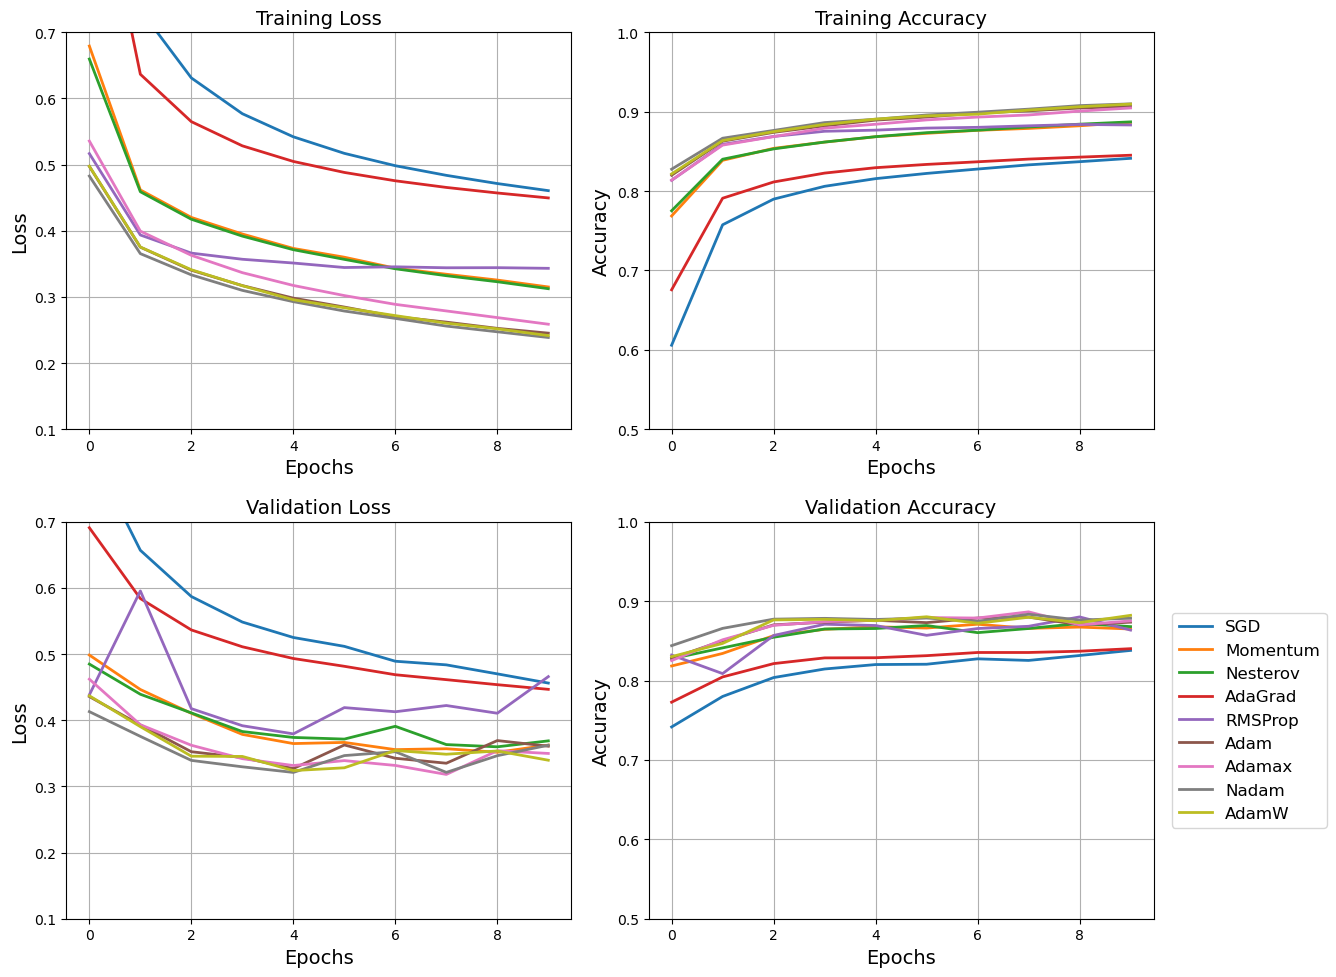

In [166]:
# extra code – visualizar curvas de entrenamiento y validación en un grid 2x2
# con una sola leyenda a la derecha

metrics = ["loss", "accuracy", "val_loss", "val_accuracy"]
titles = ["Training Loss", "Training Accuracy", "Validation Loss", "Validation Accuracy"]
opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"

plt.figure(figsize=(16, 10))  # figura grande para grid 2x2

# iterar sobre métricas y posiciones del grid
for i, (metric, title) in enumerate(zip(metrics, titles), 1):
    plt.subplot(2, 2, i)
    
    # graficar cada optimizador
    for history, opt_name in zip(
        (history_sgd, history_momentum, history_nesterov,
         history_adagrad, history_rmsprop, history_adam,
         history_adamax, history_nadam, history_adamw),
        opt_names.split()
    ):
        plt.plot(history.history[metric], label=f"{opt_name}", linewidth=2)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Epochs")
    
    # eje Y según la métrica
    if "loss" in metric:
        plt.ylabel("Loss")
        plt.ylim(0.1, 0.7)
    else:
        plt.ylabel("Accuracy")
        plt.ylim(0.5, 1.0)
    
    plt.grid(True)

# agregar una sola leyenda fuera del grid, a la derecha
plt.legend(opt_names.split(), fontsize=12, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])  # ajustar espacio dejando lugar para la leyenda
plt.show()

## Programación de la tasa de aprendizaje

1. **Tasa de aprendizaje baja**

* **Qué significa:** La red actualiza sus pesos con pasos muy pequeños.
* **Ventajas:**

  * Entrenamiento más estable.
  * Menor riesgo de “saltar” sobre mínimos locales o divergencias.
  * Mejor para redes profundas o complejas donde los gradientes pueden ser muy inestables.
* **Desventajas:**

  * Entrenamiento muy lento.
  * Puede quedarse atrapada en mínimos locales sin explorar suficientemente el espacio de parámetros.
* **Ejemplo:** 0.0001 o 0.001 en optimizadores como Adam o SGD.

2. **Tasa de aprendizaje alta**

* **Qué significa:** La red actualiza sus pesos con pasos grandes.
* **Ventajas:**

  * Convergencia rápida si se elige correctamente.
  * Puede escapar de mínimos locales poco profundos.
* **Desventajas:**

  * Riesgo de **divergencia**: el modelo nunca converge porque los pasos son demasiado grandes.
  * Oscilaciones alrededor del mínimo sin llegar a estabilizarse.
* **Ejemplo:** 0.1 en SGD puede ser demasiado alto para una red profunda, pero útil en redes simples o con normalización.

3. **Tasa de aprendizaje “altamente alta”**

* **Qué significa:** Pasos extremadamente grandes.
* **Consecuencias típicas:**

  * La pérdida puede explotar (diverge) rápidamente.
  * Los pesos cambian de manera caótica y no hay aprendizaje efectivo.
  * Generalmente, se considera **inviable** en la práctica, a menos que se use en estrategias específicas como **learning rate warmup** o **annealing** para explorar el espacio de manera controlada.
* **Ejemplo:** >0.5 o 1 en redes normales puede romper el entrenamiento.

 Recomendaciones prácticas

* Empezar con una tasa de aprendizaje **moderada** (ej. 0.001 con Adam).
* Usar **scheduladores** para disminuirla durante el entrenamiento.
* Probar un **ciclo de tasas de aprendizaje** (learning rate range test) para encontrar un valor óptimo.
* Evitar tasas “altamente altas” sin estrategias especiales, ya que normalmente llevan a divergencia.


Los **programas de aprendizaje (o learning rate schedules)** se refiere a cómo varía la tasa de aprendizaje durante el entrenamiento de una red neuronal. Cambiar la tasa de aprendizaje a lo largo del tiempo suele mejorar la convergencia y la estabilidad del entrenamiento.

### Power Scheduling


El Power Scheduling es un método de reducción de la tasa de aprendizaje que sigue una ley de potencia. La fórmula típica es:

$$ \text{learning\_rate} = \frac{\text{initial\_learning\_rate}}{(1 + \frac{\text{step}}{\text{decay\_steps}})^\text{power}} $$

Keras usa `power = 1`.

**Nota**: Los optimizadores solían tener un argumento `decay` para esto, pero quedó obsoleto. En su lugar, debe usar los planificadores en `tf.keras.optimizers.schedules`.

**Concepto central**

Durante el entrenamiento:
- Las redes neuronales necesitan pasos grandes al inicio para explorar el espacio de parámetros rápidamente.
- A medida que se acercan a un mínimo, los pasos deben hacerse más pequeños para refinar los pesos y evitar oscilar alrededor del mínimo.

El Power Decay implementa esto mediante una función de potencia aplicada al paso de entrenamiento (`step`).

**Parámetros y su efecto**

- `initial_learning_rate (η₀)`: Valor inicial de la tasa de aprendizaje. Determina cuán rápido empieza a aprender la red.
- `step`: Número actual de iteración o batch procesado, que permite calcular la evolución del LR.
- `decay_steps`: Controla la velocidad de disminución. Un valor más grande disminuye LR lentamente; uno más pequeño, más rápido.
- `power (p)`: Determina la forma de la curva de decaimiento.  
  - $p > 1$ → caída rápida al inicio, refinamiento lento después.  
  - $p = 1$ → caída suave lineal.  
  - $p < 1$ → disminución lenta, pasos grandes por más tiempo.

**Comportamiento de la función**

- Al inicio ($\text{step} = 0$): $ \text{learning\_rate} = \text{initial\_learning\_rate} $  
- A medida que `step` aumenta, $ \text{learning\_rate} $ disminuye de manera suave, permitiendo estabilidad en la convergencia y refinamiento de pesos al final del entrenamiento.

**Ventajas**

- Evita saltos bruscos como en Step Decay.
- Controla de forma precisa la velocidad de convergencia.
- Mejora la estabilidad en redes profundas y entrenamiento largo.
- Flexible: ajustando `decay_steps` y `power` se adapta a cualquier problema o arquitectura.

**Comparación con otros schedules**

| Schedule                  | Característica principal                                 |
|----------------------------|---------------------------------------------------------|
| Step Decay                 | Disminuye LR de golpe a intervalos definidos          |
| Exponential Decay          | Disminuye LR exponencialmente con cada paso/época      |
| Power Decay (esta fórmula) | Disminuye LR de manera suave según función de potencia |

In [178]:
# Definimos un schedule de aprendizaje tipo "Inverse Time Decay"
# La tasa de aprendizaje disminuye con el tiempo de manera inversamente proporcional al paso.
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,  # Tasa de aprendizaje inicial (η₀)
    decay_steps=10_000,          # Cada cuántos pasos el decaimiento se aplica
    decay_rate=1.0,              # Factor de decaimiento en la fórmula
    staircase=False              # False → LR disminuye de forma continua; True → LR disminuye en "escalones"
)

# Creamos el optimizador SGD y le asignamos el schedule definido arriba
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
# Ahora, durante el entrenamiento, la tasa de aprendizaje cambiará automáticamente según lr_schedule

El planificador `InverseTimeDecay` utiliza `learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_steps)`. Si se establece `staircase=True`, reemplaza `step / decay_step` con `floor(step / decay_step)`.

In [180]:
# Entrenamos la red neuronal usando el optimizador que tiene Power Scheduling aplicado
# build_and_train_model() es una función definida previamente que:
#   1. Construye la arquitectura del modelo (capas, activaciones, etc.)
#   2. Compila el modelo usando el optimizador proporcionado
#   3. Entrena el modelo con los datos de entrenamiento
# El resultado se guarda en 'history_power_scheduling', que normalmente contiene:
#   - history_power_scheduling.history['loss'] → la evolución de la pérdida por época
#   - history_power_scheduling.history['accuracy'] → la evolución de la exactitud por época
history_power_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6915 - accuracy: 0.7591 - val_loss: 0.4939 - val_accuracy: 0.8288
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4802 - accuracy: 0.8317 - val_loss: 0.4582 - val_accuracy: 0.8354
Epoch 3/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4351 - accuracy: 0.8458 - val_loss: 0.4135 - val_accuracy: 0.8536
Epoch 4/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.4114 - accuracy: 0.8550 - val_loss: 0.3974 - val_accuracy: 0.8626
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3930 - accuracy: 0.8623 - val_loss: 0.3916 - val_accuracy: 0.8616
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3781 - accuracy: 0.8670 - val_loss: 0.3905 - val_accuracy: 0.8630
Epoch 7/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3679 - accuracy: 0.8689 - val_loss: 0.3756 - val_accuracy:

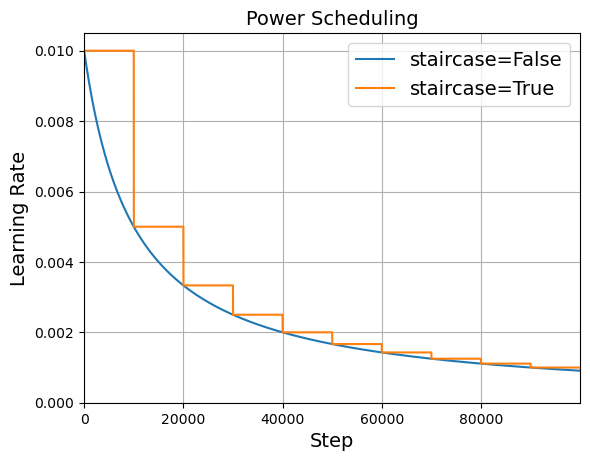

In [181]:
# Extra code – Esta celda grafica cómo varía la tasa de aprendizaje
# con Power Scheduling usando staircase=True o False

# Parámetros del schedule
initial_learning_rate = 0.01  # LR inicial
decay_rate = 1.0              # Factor de decaimiento
decay_steps = 10_000          # Cada cuántos pasos se aplica el decaimiento

# Creamos un array de pasos (steps) simulando el entrenamiento
steps = np.arange(100_000)    # 100.000 pasos de entrenamiento

# Learning rate continuo (staircase=False)
# Disminuye suavemente según la fórmula: LR = LR0 / (1 + decay_rate * step/decay_steps)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)

# Learning rate escalonado (staircase=True)
# Disminuye en “escalones” cada decay_steps usando floor
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

# Graficamos ambos schedules
plt.plot(steps, lrs, "-", label="staircase=False")  # LR continuo
plt.plot(steps, lrs2, "-", label="staircase=True") # LR en escalones
plt.axis([0, steps.max(), 0, 0.0105])             # Limites de los ejes
plt.xlabel("Step")                                # Etiqueta eje X
plt.ylabel("Learning Rate")                       # Etiqueta eje Y
plt.title("Power Scheduling", fontsize=14)       # Título del gráfico
plt.legend()                                     # Mostrar leyenda
plt.grid(True)                                   # Mostrar cuadrícula
plt.show()                                       # Renderizar gráfico

### Exponential Scheduling

El **Exponential Scheduling** es un programa de aprendizaje donde la tasa de aprendizaje **disminuye de manera exponencial con cada paso o época** durante el entrenamiento.

* Esto significa que la LR **cae rápido al inicio** y se estabiliza hacia valores más pequeños al final.
* Es muy útil cuando quieres **un inicio rápido** y **un refinamiento más fino al final**, similar a Power Scheduling, pero con una caída que sigue una función exponencial.


La fórmula es:

$ \text{learning\_rate} = \text{initial\_learning\_rate} \cdot \text{decay\_rate}^{\frac{\text{step}}{\text{decay\_steps}}} $

Concepto:

- Al inicio ($step = 0$), la tasa de aprendizaje es igual a la inicial.
- A medida que aumenta $step$, el exponente crece.
- Como $decay\_rate < 1$, la tasa de aprendizaje disminuye exponencialmente.

**Características principales**

* La LR **disminuye rápidamente al inicio** y más lentamente al final.
* Permite **convergencia estable** y evita “saltos” grandes al final.
* Puede combinarse con técnicas como **warm-up** para suavizar la fase inicial.



**Ventajas**

* Entrenamiento más rápido al principio.
* Evita divergencia en etapas finales gracias a pasos más pequeños.
* Muy usado en redes profundas y aprendizaje de visión por computadora.


 **Desventajas**

* Si $k$ es demasiado grande, la LR cae demasiado rápido y el modelo **aprende muy lento o se estanca**.
* Menos flexible que métodos adaptativos (*Reduce on Plateau*).


In [186]:
# Definimos un schedule de tasa de aprendizaje con decaimiento exponencial
# La LR disminuye multiplicativamente a medida que avanzan los pasos
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,  # Tasa de aprendizaje inicial (η₀)
    decay_steps=20_000,          # Cada cuántos pasos se aplica el factor de decaimiento
    decay_rate=0.1,              # Factor multiplicativo (<1 reduce la LR)
    staircase=False              # False → decaimiento continuo; True → en escalones
)

# Creamos el optimizador SGD usando el schedule definido
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
# Durante el entrenamiento, la tasa de aprendizaje se ajustará automáticamente según el schedule

In [187]:
# Entrenamos el modelo utilizando el optimizador con Exponential Scheduling
# build_and_train_model() es una función que:
#   - Construye la arquitectura de la red neuronal
#   - Compila el modelo con el optimizador definido (que incluye el decay exponencial)
#   - Entrena el modelo con los datos
# El resultado se guarda en 'history_exponential_scheduling', que contiene métricas del entrenamiento
# como la pérdida (loss) y la precisión (accuracy) en cada época
history_exponential_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6966 - accuracy: 0.7630 - val_loss: 0.5006 - val_accuracy: 0.8222
Epoch 2/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4726 - accuracy: 0.8344 - val_loss: 0.4555 - val_accuracy: 0.8382
Epoch 3/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4273 - accuracy: 0.8493 - val_loss: 0.4147 - val_accuracy: 0.8494
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4045 - accuracy: 0.8573 - val_loss: 0.3970 - val_accuracy: 0.8544
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3870 - accuracy: 0.8639 - val_loss: 0.3912 - val_accuracy: 0.8578
Epoch 6/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3744 - accuracy: 0.8680 - val_loss: 0.3899 - val_accuracy: 0.8596
Epoch 7/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3658 - accuracy: 0.8706 - val_loss: 0.3768 - val_accuracy:

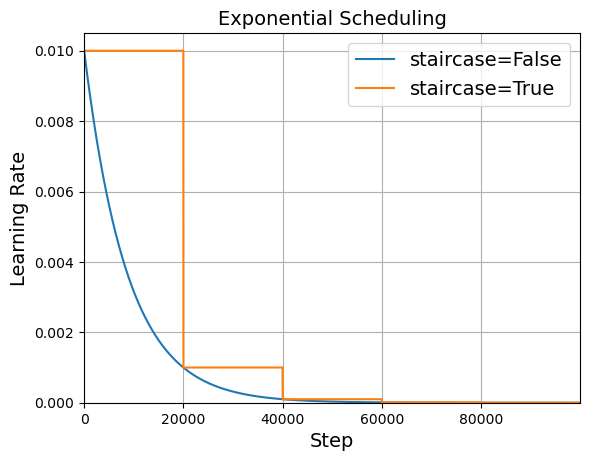

In [188]:
# Extra code – Esta celda grafica cómo cambia la tasa de aprendizaje
# usando Exponential Scheduling con y sin staircase

# Parámetros del schedule
initial_learning_rate = 0.01  # Tasa de aprendizaje inicial (η₀)
decay_rate = 0.1              # Factor de decaimiento (<1 reduce la LR exponencialmente)
decay_steps = 20_000          # Número de pasos que define la velocidad del decaimiento

# Generamos pasos de entrenamiento simulados
steps = np.arange(100_000)    # 100,000 iteraciones

# Learning rate continuo (staircase=False)
# Fórmula: LR = LR0 * decay_rate^(step / decay_steps)
# Disminuye suavemente en cada paso
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)

# Learning rate escalonado (staircase=True)
# Usa floor para que la LR cambie en bloques (escalones)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

# Graficamos ambas curvas
plt.plot(steps, lrs, "-", label="staircase=False")   # Decaimiento continuo
plt.plot(steps, lrs2, "-", label="staircase=True")  # Decaimiento por escalones

# Configuración de la gráfica
plt.axis([0, steps.max(), 0, 0.0105])  # Límites de los ejes
plt.xlabel("Step")                     # Eje X: pasos de entrenamiento
plt.ylabel("Learning Rate")            # Eje Y: tasa de aprendizaje
plt.title("Exponential Scheduling", fontsize=14)  # Título
plt.legend()                           # Mostrar leyenda
plt.grid(True)                         # Mostrar cuadrícula
plt.show()                             # Mostrar gráfica

Keras también proporciona una clase de devolución de llamada `LearningRateScheduler` que permite definir una función de programación propia. Veamos cómo se podría usar para implementar una disminución exponencial. Cabe destacar que, en este caso, la tasa de aprendizaje solo cambia en cada época, no en cada paso.

In [190]:
# Definimos una función de decaimiento exponencial basada en épocas (epoch)
def exponential_decay_fn(epoch):
    # Calcula la tasa de aprendizaje en función de la época actual
    # LR = 0.01 * 0.1^(epoch / 20)
    # - 0.01 es la tasa de aprendizaje inicial
    # - 0.1 es el decay_rate (reduce la LR exponencialmente)
    # - epoch / 20 controla la velocidad del decaimiento
    return 0.01 * 0.1 ** (epoch / 20)

In [191]:
# Definimos una función generadora de schedules de decaimiento exponencial
def exponential_decay(lr0, s):
    # Esta función devuelve otra función (closure) que calcula el learning rate
    def exponential_decay_fn(epoch):
        # Fórmula del decaimiento exponencial:
        # LR = lr0 * 0.1^(epoch / s)
        # - lr0: tasa de aprendizaje inicial
        # - epoch: época actual
        # - s: controla la velocidad del decaimiento
        return lr0 * 0.1 ** (epoch / s)
    
    # Retornamos la función interna ya configurada con lr0 y s
    return exponential_decay_fn

# Creamos una función específica con parámetros concretos
exponential_decay_fn = exponential_decay(lr0=0.01, s=20)
# Ahora exponential_decay_fn(epoch) devuelve la LR para cada época

In [192]:
# Extra code – Construcción y compilación de un modelo para Fashion MNIST

# Fijamos la semilla aleatoria para reproducibilidad
# Esto asegura que los resultados sean consistentes en cada ejecución
tf.random.set_seed(42)

# Construimos el modelo (arquitectura definida previamente en build_model())
model = build_model()

# Definimos el optimizador SGD con una tasa de aprendizaje constante
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

# Compilamos el modelo
model.compile(
    loss="sparse_categorical_crossentropy",  # Función de pérdida para clasificación multiclase con etiquetas enteras
    optimizer=optimizer,                     # Optimizador (SGD en este caso)
    metrics=["accuracy"]                     # Métrica de evaluación (precisión)
)

In [193]:
# Número de épocas de entrenamiento
n_epochs = 20

# Definimos un callback que ajusta la tasa de aprendizaje en cada época
# usando la función exponential_decay_fn definida previamente
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,                # Datos de entrenamiento
    epochs=n_epochs,                 # Número de épocas
    validation_data=(X_valid, y_valid),  # Datos de validación
    callbacks=[lr_scheduler]         # Aplicamos el scheduler en cada época
)

Epoch 1/20
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6806 - accuracy: 0.7649 - val_loss: 0.4835 - val_accuracy: 0.8302 - lr: 0.0100
Epoch 2/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4670 - accuracy: 0.8346 - val_loss: 0.4483 - val_accuracy: 0.8374 - lr: 0.0089
Epoch 3/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4216 - accuracy: 0.8493 - val_loss: 0.4164 - val_accuracy: 0.8540 - lr: 0.0079
Epoch 4/20
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3975 - accuracy: 0.8588 - val_loss: 0.3891 - val_accuracy: 0.8624 - lr: 0.0071
Epoch 5/20
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3784 - accuracy: 0.8648 - val_loss: 0.3838 - val_accuracy: 0.8648 - lr: 0.0063
Epoch 6/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3639 - accuracy: 0.8705 - val_loss: 0.3947 - val_accuracy: 0.8594 - lr: 0.0056
Epoch 7/20
1719/1719 [==============================] - 7s

Alternativamente, la función de programación puede tomar la tasa de aprendizaje actual como segundo argumento:

In [195]:
# Definimos una función de decaimiento exponencial dependiente del LR actual
def exponential_decay_fn(epoch, lr):
    # Calcula el nuevo learning rate a partir del anterior (lr)
    # LR_nuevo = LR_actual * 0.1^(1/20)
    # Esto aplica un factor de reducción constante en cada época
    return lr * 0.1 ** (1 / 20)

**Material adicional**: si desea utilizar una función de programación personalizada que actualice la tasa de aprendizaje en cada iteración en lugar de en cada época, puede escribir su propia clase de devolución de llamada como esta:

In [197]:
# Definimos un callback personalizado para decaimiento exponencial en cada batch
K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    def __init__(self, n_steps=40_000):
        # Inicializamos el callback y definimos n_steps: número total de pasos para el decaimiento
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        # Se ejecuta al inicio de cada batch
        # Nota: el argumento `batch` se reinicia en cada época
        # Obtenemos el learning rate actual
        lr = self.model.optimizer.learning_rate.numpy()
        # Calculamos el nuevo learning rate usando decaimiento exponencial
        # Cada batch se multiplica por un factor <1 para reducir LR suavemente
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        # Actualizamos la LR del optimizador
        self.model.optimizer.learning_rate = new_learning_rate

    def on_epoch_end(self, epoch, logs=None):
        # Se ejecuta al final de cada época
        logs = logs or {}
        # Guardamos el learning rate actual en los logs para poder graficarlo o monitorearlo
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

In [198]:
# Definimos parámetros y compilamos un modelo para entrenamiento

# Learning rate inicial
lr0 = 0.01

# Construimos el modelo (definido previamente en build_model)
model = build_model()

# Optimizador SGD con learning rate inicial lr0
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)

# Compilamos el modelo
model.compile(
    loss="sparse_categorical_crossentropy",  # Pérdida para clasificación multiclase con etiquetas enteras
    optimizer=optimizer,                      # Optimizador SGD
    metrics=["accuracy"]                      # Métrica de precisión
)

In [199]:
import math

# Tamaño del batch
batch_size = 32

# Calculamos el número total de pasos (batches) en todo el entrenamiento
# n_steps = n_epochs * número de batches por época
n_steps = n_epochs * math.ceil(len(X_train) / batch_size)

# Creamos un callback de decaimiento exponencial que se aplica batch a batch
exp_decay = ExponentialDecay(n_steps)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,                    # Datos de entrenamiento
    epochs=n_epochs,                      # Número de épocas
    validation_data=(X_valid, y_valid),  # Datos de validación
    callbacks=[exp_decay]                 # Aplicamos el decaimiento exponencial en cada batch
)

Epoch 1/20
1719/1719 [==============================] - 8s 4ms/step - loss: 0.6787 - accuracy: 0.7691 - val_loss: 0.4863 - val_accuracy: 0.8284 - lr: 0.0089
Epoch 2/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4691 - accuracy: 0.8336 - val_loss: 0.4555 - val_accuracy: 0.8358 - lr: 0.0079
Epoch 3/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4233 - accuracy: 0.8491 - val_loss: 0.4154 - val_accuracy: 0.8520 - lr: 0.0071
Epoch 4/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3998 - accuracy: 0.8584 - val_loss: 0.3873 - val_accuracy: 0.8616 - lr: 0.0063
Epoch 5/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3811 - accuracy: 0.8640 - val_loss: 0.3840 - val_accuracy: 0.8624 - lr: 0.0056
Epoch 6/20
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3673 - accuracy: 0.8698 - val_loss: 0.3842 - val_accuracy: 0.8640 - lr: 0.0050
Epoch 7/20
1719/1719 [==============================] - 7s

### Piecewise Constant Scheduling



**Piecewise Constant Scheduling** es un enfoque donde la tasa de aprendizaje se mantiene constante durante intervalos de entrenamiento y solo cambia en puntos predeterminados (“breakpoints”).

Utiliza una tasa de aprendizaje constante para una cantidad de épocas, luego una tasa de aprendizaje más pequeña para otra cantidad de épocas y así sucesivamente.

La fórmula general es:

$ 
\text{learning\_rate}(step) =
\begin{cases}
v_0 & \text{si } step < b_1 \\
v_1 & \text{si } b_1 \leq step < b_2 \\
\vdots \\
v_n & \text{si } step \ge b_n
\end{cases}
$

donde:

- $step$ → número de iteración o batch  
- $boundaries = [b_1, b_2, ..., b_n]$ → puntos donde la LR cambia  
- $values = [v_0, v_1, ..., v_n]$ → valores de LR en cada tramo  

**Características principales:**

- La LR es constante durante cada tramo y disminuye abruptamente en los puntos de cambio.  
- Permite usar LR alta al inicio y reducirla estratégicamente para refinamiento.  
- Muy usado en redes profundas y entrenamiento de visión por computadora.  

**Ventajas:**

- Estabilidad durante cada tramo de entrenamiento.  
- Control preciso de cuándo y cuánto disminuir la LR.  
- Compatible con datasets grandes y entrenamientos largos.  

**Desventajas:**

- Menos flexible que schedules suaves como Exponential o Power Decay.  
- Requiere definir manualmente los puntos de cambio y los valores de LR.
- Es necesario hacer pruebas para determinar la secuencia correcta de ritmos de aprendizaje y durante cuanto tiempo utilizar cada uno de ellos.

Resumen intuitivo:

Piecewise Constant Scheduling es como un termostato con pasos: mantienes la LR estable hasta un punto, luego la bajas a un nuevo valor fijo, y repites según los intervalos definidos.

In [204]:
# Definimos un schedule de tasa de aprendizaje tipo Piecewise Constant Decay
# La LR permanece constante durante intervalos definidos por `boundaries` y cambia a los valores correspondientes en `values`
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    # Puntos de cambio en pasos de entrenamiento (batches)
    boundaries=[50_000 * n_epochs // batch_size, 80_000 * n_epochs // batch_size],
    # Valores de LR para cada tramo
    # Antes del primer boundary: 0.01
    # Entre el primer y segundo boundary: 0.005
    # Después del segundo boundary: 0.001
    values=[0.01, 0.005, 0.001]
)

# Creamos el optimizador SGD usando el schedule definido
# Durante el entrenamiento, la LR se actualizará automáticamente según Piecewise Constant Decay
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [205]:
history_piecewise_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 [==============================] - 7s 3ms/step - loss: 0.6997 - accuracy: 0.7604 - val_loss: 0.4876 - val_accuracy: 0.8286
Epoch 2/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4726 - accuracy: 0.8310 - val_loss: 0.4516 - val_accuracy: 0.8332
Epoch 3/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4226 - accuracy: 0.8474 - val_loss: 0.4221 - val_accuracy: 0.8528
Epoch 4/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3968 - accuracy: 0.8589 - val_loss: 0.3839 - val_accuracy: 0.8656
Epoch 5/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3751 - accuracy: 0.8650 - val_loss: 0.3714 - val_accuracy: 0.8668
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3580 - accuracy: 0.8709 - val_loss: 0.3788 - val_accuracy: 0.8650
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3456 - accuracy: 0.8743 - val_loss: 0.3572 - val_accuracy:

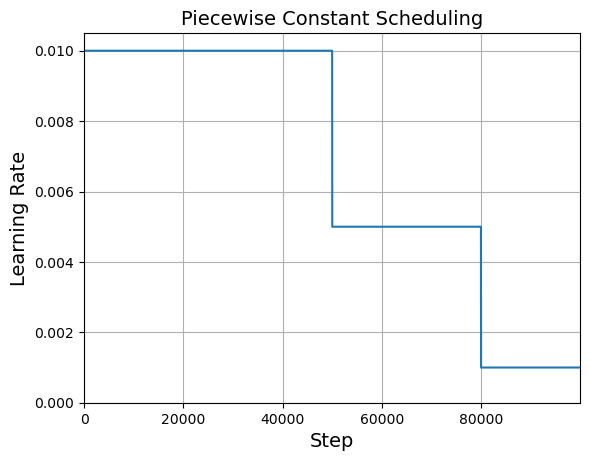

In [206]:
# Extra code – Esta celda grafica cómo cambia la tasa de aprendizaje usando Piecewise Constant Scheduling

# Definimos los puntos de cambio (boundaries) y los valores de LR en cada tramo
boundaries = [50_000, 80_000]  # Batches donde la LR cambia
values = [0.01, 0.005, 0.001]  # LR para cada tramo

# Creamos un array con todos los pasos de entrenamiento simulados
steps = np.arange(100_000)

# Inicializamos todos los pasos con el primer valor de LR
lrs = np.full(len(steps), values[0])

# Aplicamos los valores de LR en cada tramo definido por boundaries
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value  # A partir de cada boundary, la LR cambia al siguiente valor

# Graficamos la curva de LR
plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])  # Límites de los ejes
plt.xlabel("Step")                      # Eje X: pasos de entrenamiento
plt.ylabel("Learning Rate")             # Eje Y: tasa de aprendizaje
plt.title("Piecewise Constant Scheduling", fontsize=14)  # Título
plt.grid(True)                          # Mostrar cuadrícula
plt.show()

Al igual que hicimos con la planificación exponencial, también podríamos implementar manualmente la planificación constante por partes:

In [208]:
# Definimos una función de Piecewise Constant Scheduling basada en épocas
def piecewise_constant_fn(epoch):
    # Durante las primeras 5 épocas, usamos LR alta
    if epoch < 5:
        return 0.01
    # Entre la época 5 y 14, reducimos LR a un valor intermedio
    elif epoch < 15:
        return 0.005
    # A partir de la época 15 en adelante, usamos LR más baja
    else:
        return 0.001

In [209]:
# Extra code – Una forma más general de definir Piecewise Constant Scheduling

def piecewise_constant(boundaries, values):
    # Agregamos un 0 al inicio de boundaries para que coincida con el primer tramo
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    
    # Definimos la función que devuelve la LR según la época
    def piecewise_constant_fn(epoch):
        # np.argmax encuentra el primer índice donde boundary > epoch
        # Restamos 1 para obtener el índice correcto en values
        return values[(boundaries > epoch).argmax() - 1]
    
    return piecewise_constant_fn

# Creamos una función específica de Piecewise Constant Scheduling
# Tramos:
# epoch 0–4  → LR = 0.01
# epoch 5–14 → LR = 0.005
# epoch 15+  → LR = 0.001
piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

In [210]:
# Extra code – Usamos un LearningRateScheduler de Keras para aplicar Piecewise Constant Scheduling

# Número de épocas de entrenamiento
n_epochs = 25

# Creamos un callback que ajusta la LR en cada época usando la función piecewise_constant_fn
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

# Construimos el modelo
model = build_model()

# Usamos un optimizador Nadam con tasa de aprendizaje inicial lr0
optimizer = tf.keras.optimizers.Nadam(learning_rate=lr0)

# Compilamos el modelo
model.compile(
    loss="sparse_categorical_crossentropy",  # Pérdida para clasificación multiclase con etiquetas enteras
    optimizer=optimizer,                      # Optimizador Nadam
    metrics=["accuracy"]                      # Métrica de precisión
)

# Entrenamos el modelo, aplicando el scheduler de LR por época
history = model.fit(
    X_train, y_train,                          # Datos de entrenamiento
    epochs=n_epochs,                            # Número de épocas
    validation_data=(X_valid, y_valid),        # Datos de validación
    callbacks=[lr_scheduler]                    # Callback que ajusta LR según tramos
)

Epoch 1/25
1719/1719 [==============================] - 10s 4ms/step - loss: 0.5411 - accuracy: 0.8093 - val_loss: 0.4786 - val_accuracy: 0.8204 - lr: 0.0100
Epoch 2/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4523 - accuracy: 0.8421 - val_loss: 0.4485 - val_accuracy: 0.8358 - lr: 0.0100
Epoch 3/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4214 - accuracy: 0.8533 - val_loss: 0.4299 - val_accuracy: 0.8558 - lr: 0.0100
Epoch 4/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4118 - accuracy: 0.8561 - val_loss: 0.3996 - val_accuracy: 0.8580 - lr: 0.0100
Epoch 5/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4099 - accuracy: 0.8585 - val_loss: 0.4174 - val_accuracy: 0.8492 - lr: 0.0100
Epoch 6/25
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3563 - accuracy: 0.8744 - val_loss: 0.3811 - val_accuracy: 0.8628 - lr: 0.0050
Epoch 7/25
1719/1719 [==============================] - 7

Hemos analizado `InverseTimeDecay`, `ExponentialDecay` y `PiecewiseConstantDecay`. Hay algunos planificadores más disponibles en `tf.keras.optimizers.schedules`, aquí está la lista completa:

In [212]:
for name in sorted(dir(tf.keras.optimizers.schedules)):
    if name[0] == name[0].lower():  # must start with capital letter
        continue
    scheduler_class = getattr(tf.keras.optimizers.schedules, name)
    print(f"• {name} – {scheduler_class.__doc__.splitlines()[0]}")

• CosineDecay – A LearningRateSchedule that uses a cosine decay with optional warmup.
• CosineDecayRestarts – A LearningRateSchedule that uses a cosine decay schedule with restarts.
• ExponentialDecay – A LearningRateSchedule that uses an exponential decay schedule.
• InverseTimeDecay – A LearningRateSchedule that uses an inverse time decay schedule.
• LearningRateSchedule – The learning rate schedule base class.
• PiecewiseConstantDecay – A LearningRateSchedule that uses a piecewise constant decay schedule.
• PolynomialDecay – A LearningRateSchedule that uses a polynomial decay schedule.


### Performance Scheduling

Performance Scheduling es una estrategia de **ajuste de la tasa de aprendizaje (learning rate, LR) basada en el desempeño del modelo** durante el entrenamiento.  

Conceptos clave:

- **Dependencia del rendimiento**: A diferencia de otros schedules que dependen de épocas o pasos (batches), aquí la LR se ajusta según métricas del modelo, típicamente de validación, como:
  - $val\_loss$: pérdida de validación
  - $val\_accuracy$: precisión de validación

- **Reducción adaptativa**: Si la métrica monitoreada deja de mejorar durante un cierto número de épocas (`patience`), la LR se reduce automáticamente multiplicándola por un factor $0 < factor < 1$.  
  Esto permite que el modelo haga ajustes más finos cuando se aproxima a un mínimo de pérdida.



- **Implementación típica**: En Keras se implementa con el callback `ReduceLROnPlateau`, que requiere:
  - `monitor`: métrica a observar
  - `factor`: cuánto se reduce la LR cuando no hay mejora
  - `patience`: número de épocas sin mejora antes de aplicar la reducción
  - `min_lr`: LR mínima para evitar valores demasiado pequeños

- **Ventajas**:
  - Ajuste automático de la LR según el comportamiento real del modelo.
  - Ayuda a prevenir estancamiento en mínimos locales.
  - Compatible con cualquier optimizador y arquitectura.

- **Limitaciones**:
  - Requiere elegir cuidadosamente la métrica a monitorear.
  - Puede ser más lento que schedules predefinidos si la métrica fluctúa mucho.
  - Menos predecible que un schedule fijo, ya que depende del desempeño real del modelo.

Esta estrategia es especialmente útil en entrenamientos largos o cuando se usan datasets grandes, donde mantener una LR demasiado alta después de un estancamiento puede impedir la convergencia fina del modelo.

In [217]:
# Extra code – Construimos y compilamos el modelo para entrenamiento

# Creamos la arquitectura del modelo
model = build_model()

# Definimos el optimizador, aquí SGD con learning rate inicial lr0
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)

# Compilamos el modelo
# - loss: función de pérdida para clasificación con etiquetas enteras
# - optimizer: optimizador que ajusta los pesos
# - metrics: métricas que queremos monitorear durante entrenamiento
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [218]:
# Extra code – Entrenamos el modelo usando Performance Scheduling

# Creamos un callback que ajusta la LR automáticamente si la métrica deja de mejorar
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.5,   # Reduce la LR a la mitad cuando no hay mejora
    patience=5    # Espera 5 épocas sin mejora antes de reducir la LR
)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,                  # Datos de entrenamiento
    epochs=n_epochs,                    # Número de épocas
    validation_data=(X_valid, y_valid),# Datos de validación
    callbacks=[lr_scheduler]            # Callback que aplica Performance Scheduling
)

Epoch 1/25
1719/1719 [==============================] - 7s 3ms/step - loss: 0.6848 - accuracy: 0.7643 - val_loss: 0.4887 - val_accuracy: 0.8274 - lr: 0.0100
Epoch 2/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4662 - accuracy: 0.8339 - val_loss: 0.4596 - val_accuracy: 0.8294 - lr: 0.0100
Epoch 3/25
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4185 - accuracy: 0.8503 - val_loss: 0.4141 - val_accuracy: 0.8540 - lr: 0.0100
Epoch 4/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3939 - accuracy: 0.8591 - val_loss: 0.3858 - val_accuracy: 0.8654 - lr: 0.0100
Epoch 5/25
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3734 - accuracy: 0.8658 - val_loss: 0.3767 - val_accuracy: 0.8654 - lr: 0.0100
Epoch 6/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3574 - accuracy: 0.8702 - val_loss: 0.3811 - val_accuracy: 0.8662 - lr: 0.0100
Epoch 7/25
1719/1719 [==============================] - 6s

In [242]:
# Extra code – Callback que guarda la LR en cada época
class LrLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Guardamos la LR actual en los logs
        logs['learning_rate'] = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))

# Creamos el callback de ReduceLROnPlateau
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.5,   # Reduce LR a la mitad si no hay mejora
    patience=5    # Espera 5 épocas sin mejora
)

# Callback que registra la LR
lr_logger = LrLogger()

# Entrenamos el modelo con ambos callbacks
history = model.fit(
    X_train, y_train,
    epochs=n_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[lr_scheduler, lr_logger]
)

Epoch 1/25
1719/1719 [==============================] - 6s 3ms/step - loss: 0.2287 - accuracy: 0.9161 - val_loss: 0.3343 - val_accuracy: 0.8800 - lr: 0.0050 - learning_rate: 0.0050
Epoch 2/25
1719/1719 [==============================] - 6s 3ms/step - loss: 0.2270 - accuracy: 0.9182 - val_loss: 0.3197 - val_accuracy: 0.8814 - lr: 0.0050 - learning_rate: 0.0050
Epoch 3/25
1719/1719 [==============================] - 6s 4ms/step - loss: 0.2233 - accuracy: 0.9190 - val_loss: 0.3231 - val_accuracy: 0.8858 - lr: 0.0050 - learning_rate: 0.0050
Epoch 4/25
1719/1719 [==============================] - 6s 4ms/step - loss: 0.2225 - accuracy: 0.9200 - val_loss: 0.3167 - val_accuracy: 0.8864 - lr: 0.0050 - learning_rate: 0.0050
Epoch 5/25
1719/1719 [==============================] - 6s 4ms/step - loss: 0.2202 - accuracy: 0.9203 - val_loss: 0.3207 - val_accuracy: 0.8838 - lr: 0.0050 - learning_rate: 0.0050
Epoch 6/25
1719/1719 [==============================] - 6s 3ms/step - loss: 0.2170 - accuracy: 

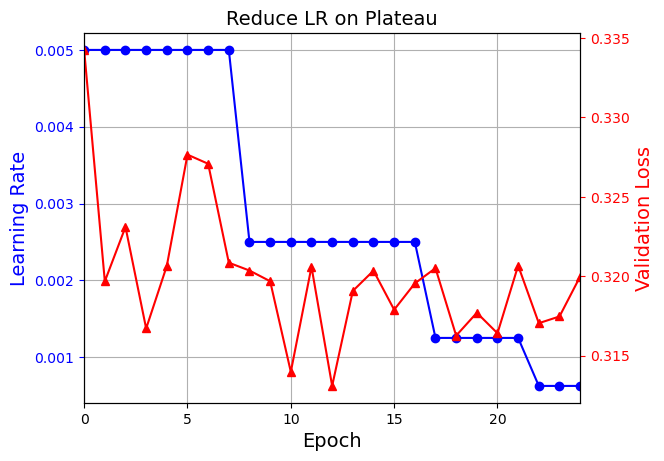

In [246]:
# Extra code – Esta celda grafica cómo cambia la LR usando Performance Scheduling (ReduceLROnPlateau)

# Graficamos la LR en azul
plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")                        # Eje X: épocas
plt.ylabel("Learning Rate", color='b')     # Eje Y izquierdo: LR
plt.tick_params('y', colors='b')           # Color azul para el eje de LR
plt.gca().set_xlim(0, n_epochs - 1)        # Limitar eje X a las épocas
plt.grid(True)                              # Mostrar cuadrícula

# Creamos un segundo eje Y para la pérdida de validación
ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")  # Graficamos val_loss en rojo
ax2.set_ylabel('Validation Loss', color='r')                 # Eje Y derecho: pérdida de validación
ax2.tick_params('y', colors='r')                              # Color rojo para el eje de val_loss

# Título de la gráfica
plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

### 1Cycle scheduling

**1Cycle Scheduling**

1Cycle Scheduling es una estrategia de ajuste dinámico del **learning rate (LR)** y opcionalmente del **momentum**, diseñada para entrenar redes neuronales más rápido y mejorar la generalización.

Concepto clave:
- Durante todo el entrenamiento, la LR sigue un **ciclo completo**: sube, baja y termina baja, en lugar de permanecer constante o decrecer lentamente.
- Se puede combinar con momentum cíclico: momentum alto cuando LR es baja y momentum bajo cuando LR es alta.

Fases del ciclo:

1. **Subida de LR**  
   - LR aumenta desde un valor bajo `lr_min` hasta un máximo `lr_max`.
   - Permite que el modelo explore el espacio de parámetros y evite mínimos locales pobres.

2. **Bajada de LR**  
   - LR disminuye de `lr_max` a `lr_min`.
   - Permite un ajuste más fino de los pesos y estabiliza el entrenamiento.

3. **Fase final (LR mínima)**  
   - LR baja hasta un valor muy pequeño `lr_final`.
   - Favorece la convergencia estable y el ajuste fino al final del entrenamiento.

Opcionalmente, el momentum se ajusta inversamente a la LR:

- Fase de LR baja → momentum alto (estabilidad)
- Fase de LR alta → momentum bajo (exploración)

Ventajas de 1Cycle Scheduling:

- **Convergencia más rápida**: el modelo encuentra mínimos de pérdida profundos en menos épocas.
- **Mejor generalización**: evita sobreajuste gracias a la exploración inicial del espacio de pesos.
- **Menor necesidad de tuning manual**: el rango de LR puede determinarse previamente con un Learning Rate Finder.
- Funciona bien con optimizadores como SGD, Adam o Nadam.

Fórmulas conceptuales:

$LR_t =
\begin{cases}
lr_{min} \rightarrow lr_{max}, & \text{fase de subida} \\
lr_{max} \rightarrow lr_{min}, & \text{fase de bajada} \\
lr_{min} \rightarrow lr_{final}, & \text{fase final}
\end{cases}$

$Momentum_t =
\begin{cases}
momentum_{max} \rightarrow momentum_{min}, & \text{fase de subida de LR} \\
momentum_{min} \rightarrow momentum_{max}, & \text{fase de bajada de LR}
\end{cases}$

Resumen intuitivo:

- 1Cycle Scheduling es como un entrenamiento deportivo:
  - Fase inicial rápida: explorar
  - Fase intermedia controlada: refinar
  - Fase final lenta: ajustar detalles
- Combinado con momentum cíclico, permite que la red aprenda de manera más eficiente y estable.

La función de devolución de llamada personalizada `ExponentialLearningRate` actualiza la tasa de aprendizaje durante el entrenamiento, al final de cada lote. La multiplica por un factor constante. También guarda la tasa de aprendizaje y la pérdida en cada lote. Dado que `logs["loss"]` es en realidad la pérdida media desde el inicio de la época, y queremos guardar la pérdida del lote, debemos calcular la media multiplicada por el número de lotes desde el inicio de la época para obtener la pérdida total acumulada hasta el momento, y luego restamos la pérdida total del lote anterior para obtener la pérdida del lote actual.

In [250]:
K = tf.keras.backend  # Alias para acceder al backend de Keras

# Definimos un callback personalizado para aplicar un decaimiento exponencial de la LR
class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        """
        factor: valor por el cual se multiplica la LR después de cada batch.
        """
        self.factor = factor
        self.rates = []   # Para almacenar el valor de LR en cada batch
        self.losses = []  # Para almacenar la pérdida de cada batch

    def on_epoch_begin(self, epoch, logs=None):
        """
        Se ejecuta al inicio de cada época.
        Inicializa el acumulador de pérdidas de la época.
        """
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        """
        Se ejecuta al final de cada batch.
        Calcula la pérdida del batch y actualiza la LR multiplicándola por factor.
        """
        # Pérdida promedio hasta este batch
        mean_epoch_loss = logs["loss"]  
        
        # Calculamos la suma total de la pérdida de la época hasta este batch
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        
        # La pérdida del batch se obtiene restando la suma anterior
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses
        
        # Guardamos el valor actual de la LR
        lr = self.model.optimizer.learning_rate.numpy()
        self.rates.append(lr)
        self.losses.append(batch_loss)
        
        # Aplicamos el decaimiento exponencial: LR *= factor
        self.model.optimizer.learning_rate = lr * self.factor

La función `find_learning_rate()` entrena el modelo utilizando la función de devolución de llamada `ExponentialLearningRate` y devuelve las tasas de aprendizaje y las pérdidas por lotes correspondientes. Finalmente, restaura el modelo y su optimizador a su estado inicial.

In [252]:
def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4, max_rate=1):
    """
    Busca un rango adecuado de learning rate usando un aumento exponencial.
    
    Parámetros:
    - model: modelo Keras ya compilado.
    - X, y: datos de entrenamiento y etiquetas.
    - epochs: número de épocas para el test de LR.
    - batch_size: tamaño de batch.
    - min_rate: LR inicial mínima.
    - max_rate: LR máxima final.

    Retorna:
    - rates: lista de LR utilizadas durante el entrenamiento.
    - losses: lista de pérdidas correspondientes a cada batch.
    """

    # Guardamos los pesos iniciales para restaurarlos después
    init_weights = model.get_weights()

    # Calculamos el número total de batches
    iterations = math.ceil(len(X) / batch_size) * epochs

    # Factor de decaimiento exponencial por batch
    factor = (max_rate / min_rate) ** (1 / iterations)

    # Guardamos la LR inicial del optimizador
    init_lr = K.get_value(model.optimizer.learning_rate)

    # Asignamos la LR mínima para empezar
    model.optimizer.learning_rate = min_rate

    # Creamos el callback personalizado de LR exponencial
    exp_lr = ExponentialLearningRate(factor)

    # Entrenamos el modelo por pocas épocas usando el callback
    # Esto es solo para testear LR, no para entrenar realmente
    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[exp_lr],
        verbose=0  # opcional, para no imprimir toda la salida
    )

    # Restauramos la LR inicial
    model.optimizer.learning_rate = init_lr

    # Restauramos los pesos iniciales del modelo
    model.set_weights(init_weights)

    # Devolvemos las LR probadas y las pérdidas por batch
    return exp_lr.rates, exp_lr.losses

La función `plot_lr_vs_loss()` grafica las tasas de aprendizaje en función de las pérdidas. La tasa de aprendizaje óptima, que se utiliza como tasa de aprendizaje máxima en 1 ciclo, se encuentra cerca del límite inferior de la curva.

In [254]:
def plot_lr_vs_loss(rates, losses):
    """
    Grafica la pérdida de entrenamiento en función de la learning rate.
    
    Parámetros:
    - rates: lista de learning rates utilizadas en cada batch.
    - losses: lista de pérdidas correspondientes a cada batch.
    """

    # Graficamos la pérdida en azul
    plt.plot(rates, losses, "b")

    # Escala logarítmica para el eje X (learning rate)
    plt.gca().set_xscale('log')

    # Calculamos un límite superior aproximado para el eje Y
    max_loss = losses[0] + min(losses)

    # Línea horizontal indicando la mínima pérdida alcanzada
    plt.hlines(min(losses), min(rates), max(rates), color="k")

    # Limites de los ejes
    plt.axis([min(rates), max(rates), 0, max_loss])

    # Etiquetas de los ejes
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")

    # Mostrar cuadrícula
    plt.grid()

Vamos a crear un modelo MNIST sencillo para la categoría Moda y a compilarlo:

In [256]:
# Extra code – Construimos y compilamos un modelo para entrenamiento

# Creamos la arquitectura del modelo (previamente definida en build_model)
model = build_model()

# Compilamos el modelo
# - loss: función de pérdida para clasificación con etiquetas enteras
# - optimizer: SGD con learning rate inicial de 0.001
# - metrics: monitorizamos la precisión durante entrenamiento y validación
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=["accuracy"]
)

Ahora vamos a encontrar la tasa de aprendizaje máxima óptima para 1 ciclo:

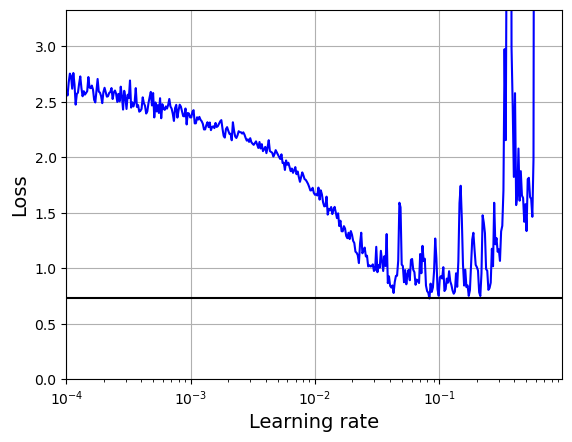

In [258]:
# Definimos el tamaño de batch para el LR Finder
batch_size = 128

# Ejecutamos la función find_learning_rate para explorar un rango de LR
# - Se entrena el modelo por 1 época
# - Se registran las LR y pérdidas por batch
rates, losses = find_learning_rate(
    model,
    X_train, y_train,
    epochs=1,
    batch_size=batch_size
)

# Graficamos la pérdida vs learning rate para identificar un rango óptimo
plot_lr_vs_loss(rates, losses)

Parece que la tasa de aprendizaje máxima a utilizar para 1 ciclo es de alrededor de 10<sup>–1</sup>.

La función de devolución de llamada personalizada `OneCycleScheduler` actualiza la tasa de aprendizaje al comienzo de cada lote. Aplica la lógica descrita en el libro: aumenta la tasa de aprendizaje linealmente durante aproximadamente la mitad del entrenamiento, luego la reduce linealmente hasta la tasa de aprendizaje inicial y, finalmente, la reduce linealmente hasta casi cero durante la última parte del entrenamiento.

In [260]:
# Callback personalizado para implementar 1Cycle Scheduling
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        """
        Inicializa el scheduler de 1Cycle.

        Parámetros:
        - iterations: número total de batches en todo el entrenamiento
        - max_lr: learning rate máxima
        - start_lr: LR inicial (si no se da, se usa max_lr / 10)
        - last_iterations: número de iteraciones finales para LR mínima (fase de ajuste fino)
        - last_lr: LR mínima final (si no se da, se usa start_lr / 1000)
        """
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0  # contador de batch actual

    def _interpolate(self, iter1, iter2, lr1, lr2):
        """
        Interpolación lineal para calcular LR en un rango de iteraciones.
        """
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        """
        Se ejecuta al inicio de cada batch para actualizar la LR según 1Cycle.
        """
        if self.iteration < self.half_iteration:
            # Fase de subida de LR
            lr = self._interpolate(0, self.half_iteration, self.start_lr, self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            # Fase de bajada de LR
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            # Fase final de ajuste fino
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)

        # Actualizamos el contador de iteración
        self.iteration += 1

        # Aplicamos la LR al optimizador del modelo
        self.model.optimizer.learning_rate = lr

Vamos a construir y compilar un modelo MNIST de moda sencillo, y luego entrenarlo usando la función de devolución de llamada `OneCycleScheduler`:

In [264]:
# Extra code – Entrenamiento del modelo usando OneCycle Scheduling

# Construimos el modelo
model = build_model()

# Compilamos el modelo
# - loss: sparse_categorical_crossentropy para etiquetas enteras
# - optimizer: SGD (sin LR fija, se controlará con OneCycleScheduler)
# - metrics: accuracy
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

# Número de épocas
n_epochs = 25

# Calculamos el número total de batches
total_iterations = math.ceil(len(X_train) / batch_size) * n_epochs

# Creamos el callback de OneCycleScheduler
onecycle = OneCycleScheduler(
    iterations=total_iterations,
    max_lr=0.1  # LR máxima durante la fase de subida
)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    validation_data=(X_valid, y_valid),
    callbacks=[onecycle]  # Aplicamos el scheduler 1Cycle
)

Epoch 1/25
430/430 [==============================] - 4s 7ms/step - loss: 0.9579 - accuracy: 0.6854 - val_loss: 0.5971 - val_accuracy: 0.7934
Epoch 2/25
430/430 [==============================] - 2s 5ms/step - loss: 0.5591 - accuracy: 0.8034 - val_loss: 0.4804 - val_accuracy: 0.8298
Epoch 3/25
430/430 [==============================] - 2s 6ms/step - loss: 0.4863 - accuracy: 0.8282 - val_loss: 0.4497 - val_accuracy: 0.8390
Epoch 4/25
430/430 [==============================] - 2s 6ms/step - loss: 0.4440 - accuracy: 0.8406 - val_loss: 0.4438 - val_accuracy: 0.8396
Epoch 5/25
430/430 [==============================] - 2s 6ms/step - loss: 0.4203 - accuracy: 0.8486 - val_loss: 0.4167 - val_accuracy: 0.8434
Epoch 6/25
430/430 [==============================] - 2s 6ms/step - loss: 0.3969 - accuracy: 0.8564 - val_loss: 0.5406 - val_accuracy: 0.7994
Epoch 7/25
430/430 [==============================] - 3s 6ms/step - loss: 0.3827 - accuracy: 0.8619 - val_loss: 0.4067 - val_accuracy: 0.8498
Epoch 

# Evitar el sobreajuste mediante la regularización

## $\ell_1$ y $\ell_2$ regularización.

| Optimizer      | Regularización L2 clásica | Recomendación               |
| -------------- | ------------------------- | --------------------------- |
| SGD            | Sí                        | Usar L2 normal              |
| SGD + Momentum | Sí                        | Usar L2 normal              |
| SGD + Nesterov | Sí                        | Usar L2 normal              |
| Adam           | No exactamente            | Usar AdamW con weight_decay |
| AdamW          | Sí                        | Usar weight_decay           |


Regularización en Deep Learning

La regularización es un conjunto de técnicas que se utilizan para **prevenir el sobreajuste (overfitting)** en redes neuronales profundas. 
El sobreajuste ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, incluyendo ruido o detalles irrelevantes, y pierde capacidad de generalización en datos nuevos.

Objetivos de la regularización:
- Mejorar la **generalización** del modelo.
- Evitar que la red aprenda patrones espurios de los datos.
- Controlar la **complejidad del modelo**.

Principales técnicas de regularización:

1. **L1 y L2 (weight decay)**
   - Añaden un término de penalización al costo de la función de pérdida.
   - L1: $\lambda \sum_i |w_i|$ → favorece pesos dispersos, muchos ceros.
   - L2: $\lambda \sum_i w_i^2$ → penaliza pesos grandes, favorece estabilidad.
   - En Keras: `kernel_regularizer=tf.keras.regularizers.l2(0.01)`.

2. **Dropout**
   - Durante el entrenamiento, se “apagan” aleatoriamente algunas neuronas con probabilidad $p$.
   - Previene que ciertas neuronas dominen el aprendizaje.
   - En Keras: `tf.keras.layers.Dropout(0.5)`.

3. **Early Stopping**
   - Detiene el entrenamiento cuando la pérdida de validación deja de mejorar.
   - Evita sobreentrenar el modelo en los datos de entrenamiento.
   - En Keras: `tf.keras.callbacks.EarlyStopping(patience=5)`.

4. **Data Augmentation**
   - Genera versiones modificadas de los datos de entrenamiento (rotaciones, zoom, recortes).
   - Aumenta la diversidad del dataset y reduce el sobreajuste.

5. **Batch Normalization**
   - Normaliza las activaciones de cada batch.
   - Actúa como un efecto de regularización al reducir la dependencia de pesos específicos.

6. **Noise Injection**
   - Añadir ruido a los datos de entrada o a las activaciones durante el entrenamiento.
   - Ayuda a que la red sea más robusta a variaciones.

Resumen conceptual:

- Regularización es **clave para modelos profundos**, porque redes profundas tienen muchos parámetros y pueden memorizar los datos de entrenamiento fácilmente.
- Combinar varias técnicas suele ser más efectivo: por ejemplo, Dropout + L2 + EarlyStopping.
- El objetivo final es **maximizar la capacidad de generalización** sin sacrificar la precisión en los datos de entrenamiento.


In [270]:
# Creamos una capa densa (fully connected) con 100 neuronas
layer = tf.keras.layers.Dense(
    100,                           # Número de neuronas en la capa
    activation="relu",             # Función de activación ReLU
    kernel_initializer="he_normal",# Inicialización de pesos He (buena para ReLU)
    kernel_regularizer=tf.keras.regularizers.l2(0.01) 
    # L2 regularization (weight decay) para prevenir sobreajuste
)

O utilice `l1(0.1)` para la regularización ℓ<sub>1</sub> con un factor de 0.1, o `l1_l2(0.1, 0.01)` para la regularización ℓ<sub>1</sub> y ℓ<sub>2</sub>, con factores de 0.1 y 0.01 respectivamente.

In [273]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [277]:
from functools import partial
import tensorflow as tf

# Creamos una versión “preconfigurada” de Dense con regularización L2 y ReLU
RegularizedDense = partial(
    tf.keras.layers.Dense,
    activation="relu",                   # Activación ReLU por defecto
    kernel_initializer="he_normal",      # Inicialización He, buena para ReLU
    kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
)
RegularizedDense 

functools.partial(<class 'keras.src.layers.core.dense.Dense'>, activation='relu', kernel_initializer='he_normal', kernel_regularizer=<keras.src.regularizers.L2 object at 0x000002530CC87E90>)

In [279]:
# Construimos un modelo secuencial
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # Aplanamos la entrada de 28x28 píxeles
    RegularizedDense(100),                          # Capa densa con 100 neuronas y regularización L2
    RegularizedDense(100),                          # Otra capa densa con las mismas configuraciones
    RegularizedDense(
        10,                                        # Capa de salida con 10 neuronas (para clasificación de 10 clases)
        activation="softmax",                       # Softmax para probabilidades
        kernel_initializer="glorot_normal"         # Inicialización Glorot (Xavier) para la capa de salida
        # Nota: no usamos L2 aquí, porque es la capa de salida
    )
])

In [281]:
model.summary()

Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_22 (Flatten)        (None, 784)               0         
                                                                 
 dense_89 (Dense)            (None, 100)               78500     
                                                                 
 dense_90 (Dense)            (None, 100)               10100     
                                                                 
 dense_91 (Dense)            (None, 10)                1010      
                                                                 
Total params: 89610 (350.04 KB)
Trainable params: 89610 (350.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [283]:
# Extra code – Compilar y entrenar el modelo

# Definimos el optimizador SGD con una learning rate inicial de 0.02
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)

# Compilamos el modelo
model.compile(
    loss="sparse_categorical_crossentropy",  # Función de pérdida para clasificación multiclase con etiquetas enteras
    optimizer=optimizer,                      # Optimizador definido arriba
    metrics=["accuracy"]                      # Métrica para evaluar desempeño durante el entrenamiento
)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,                         # Datos de entrenamiento
    epochs=2,                                 # Número de épocas de entrenamiento
    validation_data=(X_valid, y_valid)       # Datos de validación para monitorear sobreajuste
)

Epoch 1/2
1719/1719 [==============================] - 7s 4ms/step - loss: 3.1366 - accuracy: 0.7688 - val_loss: 1.8661 - val_accuracy: 0.8212
Epoch 2/2
1719/1719 [==============================] - 6s 3ms/step - loss: 1.4301 - accuracy: 0.8122 - val_loss: 1.1301 - val_accuracy: 0.8152


## Dropout

Es un algoritmo simple: En cada paso de entrenamiento, cada neurona (incluidas las neuronas de entrada, pero siempre excluidas las neuronas de salida) tiene una probabilidad $p$ de ser "desactivada" temporalmente, lo que significa que será completamente ignorada durante este paso de entrenamiento, pero puede estar activa durante el siguiente paso.

El hiperpárametro $p$ se denomina **tasa de abandono** y suele estar entre el $10$% y el $50$%:
- Cerca del $20$% al $30$% para **redenes neuronales recurrentes**.
- Cerca del $40$% al $50$% en **redes neuronales convolucionales**


Dropout es una técnica de **regularización** para redes neuronales que ayuda a prevenir el **sobreajuste** durante el entrenamiento.



Idea principal:
- Durante cada paso de entrenamiento, se "apagan" aleatoriamente un porcentaje de neuronas (junto con sus conexiones) en una capa.
- Esto fuerza a la red a no depender demasiado de neuronas específicas, promoviendo **representaciones más robustas** y redundantes.

Cómo funciona:
- Sea $p$ la probabilidad de **dropout** (por ejemplo, $p=0.5$):
  - Cada neurona tiene probabilidad $p$ de ser desactivada temporalmente durante el entrenamiento.
  - Las neuronas desactivadas no contribuyen ni a la salida ni al gradiente durante ese batch.
- En la fase de prueba, **todas las neuronas se usan**, pero sus salidas se escalan por $1-p$ para mantener la misma magnitud de activaciones esperadas.

Ventajas:
- Reduce el **sobreajuste** al impedir que la red dependa de combinaciones específicas de neuronas.
- Funciona como un **promedio de muchas redes más pequeñas**, ya que cada mini-batch entrena una subred diferente.
- Fácil de implementar y compatible con la mayoría de optimizadores.

En Keras:
```python
tf.keras.layers.Dropout(rate=0.5)

En la práctica, normalmente se puede aplicar la eliminación solo a las neuronas de la primera a las $3$ capas superiores (excluyendo la capa de salida).

**Estrategia práctica de Dropout**
- **Si hay sobreajuste** (la red aprende muy bien los datos de entrenamiento pero falla en validación):
    - Incrementa la tasa de dropout (rate): más neuronas se apagan durante entrenamiento.
    - Esto fuerza a la red a aprender representaciones más robustas, reduciendo dependencia de neuronas específicas.
    - Ejemplo: pasar de rate=0.2 a rate=0.5.
- **Si hay subajuste** (la red no aprende bien ni en entrenamiento ni en validación):
    - Reduce la tasa de dropout: deja más neuronas activas para que la red tenga suficiente capacidad de aprendizaje.
    - Ejemplo: pasar de rate=0.5 a rate=0.2 o incluso 0 (sin dropout).

- Aumentar la tasa de abandono para capas grandes y reducirla para capas pequeñas.
- Muchas arquitecturas de vamguardia solo utilizan el abandono después de la última capa oculta.

In [288]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [304]:
# Modelo secuencial con Dropout para regularización

model = tf.keras.Sequential([

    # Aplanamos la entrada 28x28 píxeles a un vector de 784 elementos
    tf.keras.layers.Flatten(input_shape=[28, 28]),

    # Dropout inicial: apaga el 20% de las neuronas de entrada para prevenir sobreajuste
    tf.keras.layers.Dropout(rate=0.2),

    # Primera capa densa con 100 neuronas y activación ReLU
    tf.keras.layers.Dense(
        100,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    # Dropout después de la primera capa densa
    tf.keras.layers.Dropout(rate=0.2),

    # Segunda capa densa con 100 neuronas y activación ReLU
    tf.keras.layers.Dense(
        100,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    # Dropout después de la segunda capa densa
    tf.keras.layers.Dropout(rate=0.2),

    # Capa de salida con 10 neuronas (para 10 clases) y activación softmax
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [306]:
# Extra code – Compilar y entrenar el modelo con Dropout

# Definimos el optimizador SGD con momentum
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,  # Learning rate inicial
    momentum=0.9         # Momentum para acelerar la convergencia y suavizar los gradientes
)

# Compilamos el modelo
model.compile(
    loss="sparse_categorical_crossentropy",  # Pérdida para clasificación multiclase con etiquetas enteras
    optimizer=optimizer,                      # Optimizador definido arriba
    metrics=["accuracy"]                      # Métrica de evaluación
)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,                         # Datos de entrenamiento
    epochs=10,                                # Número de épocas
    validation_data=(X_valid, y_valid)       # Datos de validación para monitorear sobreajuste
)

Epoch 1/10
1719/1719 [==============================] - 12s 5ms/step - loss: 0.6777 - accuracy: 0.7523 - val_loss: 0.4459 - val_accuracy: 0.8342
Epoch 2/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5180 - accuracy: 0.8119 - val_loss: 0.4097 - val_accuracy: 0.8520
Epoch 3/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4789 - accuracy: 0.8241 - val_loss: 0.3992 - val_accuracy: 0.8560
Epoch 4/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4536 - accuracy: 0.8337 - val_loss: 0.3865 - val_accuracy: 0.8552
Epoch 5/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4436 - accuracy: 0.8377 - val_loss: 0.3744 - val_accuracy: 0.8598
Epoch 6/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4277 - accuracy: 0.8424 - val_loss: 0.3652 - val_accuracy: 0.8640
Epoch 7/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4156 - accuracy: 0.8474 - val_loss: 0.3479 - val_accuracy

La precisión de entrenamiento parece ser menor que la precisión de validación, pero eso se debe simplemente a que el dropout solo está activo durante el entrenamiento. Si evaluamos el modelo en el conjunto de entrenamiento después del entrenamiento (es decir, con el dropout desactivado), obtenemos la precisión de entrenamiento "real", que es ligeramente superior a la precisión de validación y a la precisión de prueba:

In [308]:
# Evaluamos el modelo en los datos de entrenamiento
# Esto devuelve la pérdida y la métrica (accuracy) definida al compilar
train_loss, train_accuracy = model.evaluate(X_train, y_train)

print(f"Pérdida en entrenamiento: {train_loss:.4f}")
print(f"Accuracy en entrenamiento: {train_accuracy:.4f}")

1719/1719 [==============================] - 4s 3ms/step - loss: 0.3149 - accuracy: 0.8821
Pérdida en entrenamiento: 0.3149
Accuracy en entrenamiento: 0.8821


In [309]:
# Evaluamos el modelo en los datos de prueba
# Devuelve la pérdida y la métrica (accuracy) del modelo sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Pérdida en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")

313/313 [==============================] - 1s 3ms/step - loss: 0.3703 - accuracy: 0.8649
Pérdida en test: 0.3703
Accuracy en test: 0.8649


**Nota**: asegúrese de usar `AlphaDropout` (preserva ña media y desviación estándar de sus entradas). en lugar de `Dropout` si desea construir una red neuronal auto-normalizante usando SELU.

## MC Dropout

**MC Dropout (Monte Carlo Dropout)** es una técnica que extiende el concepto de Dropout para obtener estimaciones de **incertidumbre** en redes neuronales profundas. Fue propuesta por Yarin Gal y Zoubin Ghahramani (2016) como una aproximación práctica a las **redes neuronales bayesianas**.

**Principios clave:**

- Durante el entrenamiento, Dropout apaga aleatoriamente un porcentaje de neuronas para **regularizar** la red y prevenir sobreajuste.
- MC Dropout activa **Dropout también en inferencia**, realizando múltiples predicciones con la misma entrada.
- Cada predicción con Dropout activo es ligeramente diferente, simulando una **distribución de posibles salidas**.

**Estimación de incertidumbre:**

- Repetir T predicciones con Dropout activo:
  $y_1, y_2, ..., y_T$
- Predicción final:
  $\hat{y} = \frac{1}{T} \sum_{t=1}^{T} y_t$
- Varianza de las predicciones como medida de incertidumbre:
  $Var(y) = \frac{1}{T} \sum_{t=1}^{T} (y_t - \hat{y})^2$

**Ventajas:**

- Proporciona una **medida de confianza** en las predicciones de la red.
- Permite detectar entradas para las que la red es **menos segura**, útil en áreas críticas como medicina o conducción autónoma.
- Compatible con cualquier red entrenada con Dropout, sin necesidad de modificar la arquitectura.

**Resumen conceptual:**

- MC Dropout = Dropout aplicado en **entrenamiento y test**.
- Se obtiene un **promedio de predicciones** como resultado y **varianza** como indicador de incertidumbre.
- Cuantas más predicciones Monte Carlo se hagan, más precisa será la estimación de incertidumbre.

In [317]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [319]:
# Extra code – Aplicación de MC Dropout para estimar la predicción promedio

# Realizamos 100 predicciones con Dropout activo (training=True)
# Cada predicción apaga aleatoriamente neuronas según la tasa de Dropout definida
y_probas = np.stack([
    model(X_test, training=True)  # Dropout activo durante inferencia
    for sample in range(100)      # 100 muestras Monte Carlo
])

# Calculamos la predicción promedio a partir de las 100 muestras
# Esto simula la media de la distribución bayesiana aproximada de la salida
y_proba = y_probas.mean(axis=0)

In [320]:
# Realizamos una predicción para el primer ejemplo del conjunto de test
# model.predict devuelve la probabilidad de cada clase
# round(3) redondea las probabilidades a 3 decimales para visualización

prediction = model.predict(X_test[:1]).round(3)
print(prediction)

1/1 [==============================] - 0s 323ms/step
[[0.    0.    0.    0.    0.    0.013 0.    0.259 0.    0.728]]


In [323]:
# Mostramos las probabilidades promedio para el primer ejemplo
# y_proba se calculó anteriormente como la media de 100 predicciones con Dropout activo
# round(3) redondea a 3 decimales para una visualización más clara

y_proba[0].round(3)

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.033, 0.   , 0.308, 0.001,
       0.657], dtype=float32)

In [325]:
# Calculamos la desviación estándar de las predicciones Monte Carlo
# Esto nos da una medida de incertidumbre para cada clase

y_std = y_probas.std(axis=0)  # std a lo largo de las 100 predicciones
y_std[0].round(3)             # Mostramos la incertidumbre para el primer ejemplo

array([0.   , 0.   , 0.   , 0.001, 0.   , 0.049, 0.   , 0.188, 0.004,
       0.2  ], dtype=float32)

In [327]:
# Calculamos la predicción final por clase
# y_proba es la media de todas las predicciones Monte Carlo
y_pred = y_proba.argmax(axis=1)  # Clase con mayor probabilidad para cada ejemplo

# Calculamos la precisión
accuracy = (y_pred == y_test).sum() / len(y_test)  # Proporción de predicciones correctas

# Mostramos la precisión
accuracy

0.8664

In [329]:
# Definimos una clase personalizada MCDropout
# Hereda de tf.keras.layers.Dropout
# La idea es forzar Dropout activo incluso en inferencia

class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        # Llamamos al método original de Dropout pero forzamos training=True
        # Esto activa Dropout siempre, incluso durante la predicción
        return super().call(inputs, training=True)

In [331]:
# Extra code – Convertimos todas las capas Dropout de un modelo a MCDropout

# Guardamos la clase Dropout original para la verificación de tipo
Dropout = tf.keras.layers.Dropout

# Creamos un nuevo modelo secuencial
# Recorremos cada capa del modelo original
mc_model = tf.keras.Sequential([
    # Si la capa es Dropout, reemplazamos por MCDropout conservando la misma tasa
    MCDropout(layer.rate) if isinstance(layer, Dropout) else layer
    # En caso contrario, dejamos la capa tal cual
    for layer in model.layers
])

# Copiamos los pesos del modelo original al modelo MC Dropout
mc_model.set_weights(model.get_weights())

In [333]:
# Mostramos un resumen de la arquitectura del modelo con MC Dropout
# Esto incluye las capas, sus formas de salida y el número de parámetros
mc_model.summary()

Model: "sequential_26"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_23 (Flatten)        (None, 784)               0         
                                                                 
 mc_dropout (MCDropout)      (None, 784)               0         
                                                                 
 dense_92 (Dense)            (None, 100)               78500     
                                                                 
 mc_dropout_1 (MCDropout)    (None, 100)               0         
                                                                 
 dense_93 (Dense)            (None, 100)               10100     
                                                                 
 mc_dropout_2 (MCDropout)    (None, 100)               0         
                                                                 
 dense_94 (Dense)            (None, 10)              

Ahora podemos usar el modelo con MC Dropout:

In [336]:
# Extra code – demostramos que MC Dropout funciona con el modelo ya entrenado
# Se realizan 100 forward passes con Dropout activo para el primer ejemplo del test set

tf.random.set_seed(42)  # Fijamos la semilla para reproducibilidad
mc_predictions = np.mean(
    [mc_model.predict(X_test[:1])  # Predicción con Dropout activo
     for sample in range(100)],       # Repetimos 100 veces
    axis=0                            # Promediamos sobre todas las predicciones
).round(2)                            # Redondeamos a 2 decimales para visualización

mc_predictions

1/1 [==============================] - 0s 50ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.04, 0.  , 0.29, 0.  , 0.67]],
      dtype=float32)

## Max norm

**Regularización de Norma Máxima (Max-Norm Regularization)**

La **regularización de norma máxima** es una técnica que limita el tamaño de los pesos de las neuronas para **prevenir el sobreajuste y mantener la estabilidad durante el entrenamiento**.

 **Concepto**

* Cada neurona tiene un vector de pesos $ \mathbf{w} $.
* Se define un límite máximo ( $c$ ) para la **norma de los pesos**, típicamente la norma L2:

$$
|\mathbf{w}|_2 \le c
$$

* Si la norma excede ( $c$ ), los pesos se **escalan** proporcionalmente para que cumplan el límite:

$$
\text{si } |\mathbf{w}|_2 > c, \quad \mathbf{w} \gets \mathbf{w} \cdot \frac{c}{|\mathbf{w}|_2}
$$

**Propósito y Beneficios**

1. **Control del sobreajuste**

   * Evita que unos pocos pesos dominen la salida de la red.
   * Mantiene los valores de los pesos dentro de un rango razonable.

2. **Complemento a otras regularizaciones**

   * Funciona bien junto con **L1, L2** y **Dropout**.

3. **Estabilidad del entrenamiento**

   * Previene que los pesos crezcan demasiado rápido, especialmente con optimizadores de **momentum**.
   * Reduce el riesgo de explosiones de gradiente.

4. **Flexibilidad**

   * Se puede aplicar por capa, o incluso por subconjuntos de neuronas.

**Consideraciones:**

* El límite ( c ) suele elegirse mediante validación: valores comunes son entre 2 y 4.
* Es especialmente útil en redes profundas donde los pesos tienden a crecer mucho con la retropropagación.

In [353]:
# Creamos una capa Dense con regularización de norma máxima

dense = tf.keras.layers.Dense(
    100,                           # 100 neuronas en la capa
    activation="relu",             # Función de activación ReLU
    kernel_initializer="he_normal",# Inicialización He para activación ReLU
    kernel_constraint=tf.keras.constraints.max_norm(1.)  # Regularización de norma máxima con límite 1
)

In [355]:
# Extra code – aplicamos Max-Norm a cada capa oculta usando partial

from functools import partial
import tensorflow as tf

# Creamos una versión "preconfigurada" de Dense con Max-Norm
MaxNormDense = partial(
    tf.keras.layers.Dense,
    activation="relu",                    # ReLU como activación
    kernel_initializer="he_normal",       # Inicialización He Normal
    kernel_constraint=tf.keras.constraints.max_norm(1.)  # Regularización de norma máxima
)

# Fijamos semilla para reproducibilidad
tf.random.set_seed(42)

# Definimos la arquitectura del modelo
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # Aplanamos imágenes 28x28
    MaxNormDense(100),  # Primera capa oculta con Max-Norm
    MaxNormDense(100),  # Segunda capa oculta con Max-Norm
    tf.keras.layers.Dense(10, activation="softmax")  # Capa de salida
])

# Optimizador con SGD + momentum
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# Compilamos el modelo
model.compile(
    loss="sparse_categorical_crossentropy",  # Función de pérdida
    optimizer=optimizer,                     # Optimizador
    metrics=["accuracy"]                     # Métrica de evaluación
)

# Entrenamos el modelo durante 10 épocas
history = model.fit(
    X_train, y_train,                    # Datos de entrenamiento
    epochs=10,                            # Número de épocas
    validation_data=(X_valid, y_valid)   # Datos de validación
)

Epoch 1/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.5413 - accuracy: 0.8046 - val_loss: 0.4330 - val_accuracy: 0.8354
Epoch 2/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4076 - accuracy: 0.8514 - val_loss: 0.4041 - val_accuracy: 0.8444
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3767 - accuracy: 0.8607 - val_loss: 0.3780 - val_accuracy: 0.8660
Epoch 4/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3579 - accuracy: 0.8684 - val_loss: 0.3573 - val_accuracy: 0.8698
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3423 - accuracy: 0.8726 - val_loss: 0.3396 - val_accuracy: 0.8708
Epoch 6/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3376 - accuracy: 0.8751 - val_loss: 0.4266 - val_accuracy: 0.8598
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3303 - accuracy: 0.8765 - val_loss: 0.3970 - val_accuracy:

# Exercises

## 1. to 7.

1. Glorot initialization and He initialization were designed to make the output standard deviation as close as possible to the input standard deviation, at least at the beginning of training. This reduces the vanishing/exploding gradients problem.
2. No, all weights should be sampled independently; they should not all have the same initial value. One important goal of sampling weights randomly is to break symmetry: if all the weights have the same initial value, even if that value is not zero, then symmetry is not broken (i.e., all neurons in a given layer are equivalent), and backpropagation will be unable to break it. Concretely, this means that all the neurons in any given layer will always have the same weights. It's like having just one neuron per layer, and much slower. It is virtually impossible for such a configuration to converge to a good solution.
3. It is perfectly fine to initialize the bias terms to zero. Some people like to initialize them just like weights, and that's OK too; it does not make much difference.
4. ReLU is usually a good default for the hidden layers, as it is fast and yields good results. Its ability to output precisely zero can also be useful in some cases (e.g., see Chapter 17). Moreover, it can sometimes benefit from optimized implementations as well as from hardware acceleration. The leaky ReLU variants of ReLU can improve the model's quality without hindering its speed too much compared to ReLU. For large neural nets and more complex problems, GLU, Swish and Mish can give you a slightly higher quality model, but they have a computational cost. The hyperbolic tangent (tanh) can be useful in the output layer if you need to output a number in a fixed range (by default between –1 and 1), but nowadays it is not used much in hidden layers, except in recurrent nets. The sigmoid activation function is also useful in the output layer when you need to estimate a probability (e.g., for binary classification), but it is rarely used in hidden layers (there are exceptions—for example, for the coding layer of variational autoencoders; see Chapter 17). The softplus activation function is useful in the output layer when you need to ensure that the output will always be positive. The softmax activation function is useful in the output layer to estimate probabilities for mutually exclusive classes, but it is rarely (if ever) used in hidden layers.
5. If you set the `momentum` hyperparameter too close to 1 (e.g., 0.99999) when using an `SGD` optimizer, then the algorithm will likely pick up a lot of speed, hopefully moving roughly toward the global minimum, but its momentum will carry it right past the minimum. Then it will slow down and come back, accelerate again, overshoot again, and so on. It may oscillate this way many times before converging, so overall it will take much longer to converge than with a smaller `momentum` value.
6. One way to produce a sparse model (i.e., with most weights equal to zero) is to train the model normally, then zero out tiny weights. For more sparsity, you can apply ℓ<sub>1</sub> regularization during training, which pushes the optimizer toward sparsity. A third option is to use the TensorFlow Model Optimization Toolkit.
7. Yes, dropout does slow down training, in general roughly by a factor of two. However, it has no impact on inference speed since it is only turned on during training. MC Dropout is exactly like dropout during training, but it is still active during inference, so each inference is slowed down slightly. More importantly, when using MC Dropout you generally want to run inference 10 times or more to get better predictions. This means that making predictions is slowed down by a factor of 10 or more.

## 8. Deep Learning on CIFAR10

### a.
*Exercise: Build a DNN with 20 hidden layers of 100 neurons each (that's too many, but it's the point of this exercise). Use He initialization and the Swish activation function.*

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    activation="swish",
                                    kernel_initializer="he_normal"))

### b.
*Exercise: Using Nadam optimization and early stopping, train the network on the CIFAR10 dataset. You can load it with `tf.keras.datasets.cifar10.load_data()`. The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes, so you'll need a softmax output layer with 10 neurons. Remember to search for the right learning rate each time you change the model's architecture or hyperparameters.*

Let's add the output layer to the model:

In [ ]:
model.add(tf.keras.layers.Dense(10, activation="softmax"))

Let's use a Nadam optimizer with a learning rate of 5e-5. I tried learning rates 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3 and 1e-2, and I compared their learning curves for 10 epochs each (using the TensorBoard callback, below). The learning rates 3e-5 and 1e-4 were pretty good, so I tried 5e-5, which turned out to be slightly better.

In [ ]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-5)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

Let's load the CIFAR10 dataset. We also want to use early stopping, so we need a validation set. Let's use the first 5,000 images of the original training set as the validation set:

In [ ]:
cifar10 = tf.keras.datasets.cifar10.load_data()
(X_train_full, y_train_full), (X_test, y_test) = cifar10

X_train = X_train_full[5000:]
y_train = y_train_full[5000:]
X_valid = X_train_full[:5000]
y_valid = y_train_full[:5000]

Now we can create the callbacks we need and train the model:

In [ ]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./my_cifar10_logs

In [ ]:
model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

In [ ]:
model.evaluate(X_valid, y_valid)

The model with the lowest validation loss gets about 46.8% accuracy on the validation set. It took 29 epochs to reach the lowest validation loss, with roughly 10 seconds per epoch on my laptop (without a GPU). Let's see if we can improve the model using Batch Normalization.

### c.
*Exercise: Now try adding Batch Normalization and compare the learning curves: Is it converging faster than before? Does it produce a better model? How does it affect training speed?*

The code below is very similar to the code above, with a few changes:

* I added a BN layer after every Dense layer (before the activation function), except for the output layer.
* I changed the learning rate to 5e-4. I experimented with 1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 5e-4, 1e-3 and 3e-3, and I chose the one with the best validation performance after 20 epochs.
* I renamed the run directories to run_bn_* and the model file name to `my_cifar10_bn_model`.

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100, kernel_initializer="he_normal"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation("swish"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_bn_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_bn_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid, y_valid)

* *Is the model converging faster than before?* Much faster! The previous model took 29 epochs to reach the lowest validation loss, while the new model achieved that same loss in just 12 epochs and continued to make progress until the 17th epoch. The BN layers stabilized training and allowed us to use a much larger learning rate, so convergence was faster.
* *Does BN produce a better model?* Yes! The final model is also much better, with 50.7% validation accuracy instead of 46.7%. It's still not a very good model, but at least it's much better than before (a Convolutional Neural Network would do much better, but that's a different topic, see chapter 14).
* *How does BN affect training speed?* Although the model converged much faster, each epoch took about 15s instead of 10s, because of the extra computations required by the BN layers. But overall the training time (wall time) to reach the best model was shortened by about 10%.

### d.
*Exercise: Try replacing Batch Normalization with SELU, and make the necessary adjustements to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.).*

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=7e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_selu_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_selu_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

This model reached the first model's validation loss in just 8 epochs. After 14 epochs, it reached its lowest validation loss, with about 50.3% accuracy, which is better than the original model (46.7%), but not quite as good as the model using batch normalization (50.7%). Each epoch took only 9 seconds. So it's the fastest model to train so far.

### e.
*Exercise: Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC Dropout.*

**Warning**: there are now two versions of `AlphaDropout`. One is deprecated and also broken in some recent versions of TF, and unfortunately that's the version in the `tensorflow` library. Luckily, there's a perfectly fine version in the `keras` library (i.e., `keras`, not `tf.keras`). It's neither deprecated nor broken, so let's import and use that one:

In [ ]:
import keras.layers

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_alpha_dropout_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_alpha_dropout_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

The model reaches 48.1% accuracy on the validation set. That's worse than without dropout (50.3%). With an extensive hyperparameter search, it might be possible to do better (I tried dropout rates of 5%, 10%, 20% and 40%, and learning rates 1e-4, 3e-4, 5e-4, and 1e-3), but probably not much better in this case.

Let's use MC Dropout now. We will need the `MCAlphaDropout` class we used earlier, so let's just copy it here for convenience:

In [ ]:
class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

Now let's create a new model, identical to the one we just trained (with the same weights), but with `MCAlphaDropout` dropout layers instead of `AlphaDropout` layers:

In [ ]:
mc_model = tf.keras.Sequential([
    (
        MCAlphaDropout(layer.rate)
        if isinstance(layer, keras.layers.AlphaDropout)
        else layer
    )
    for layer in model.layers
])

Then let's add a couple utility functions. The first will run the model many times (10 by default) and it will return the mean predicted class probabilities. The second will use these mean probabilities to predict the most likely class for each instance:

In [ ]:
def mc_dropout_predict_probas(mc_model, X, n_samples=10):
    Y_probas = [mc_model.predict(X) for sample in range(n_samples)]
    return np.mean(Y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, X, n_samples=10):
    Y_probas = mc_dropout_predict_probas(mc_model, X, n_samples)
    return Y_probas.argmax(axis=1)

Now let's make predictions for all the instances in the validation set, and compute the accuracy:

In [ ]:
tf.random.set_seed(42)

y_pred = mc_dropout_predict_classes(mc_model, X_valid_scaled)
accuracy = (y_pred == y_valid[:, 0]).mean()
accuracy

We get back to roughly the accuracy of the model without dropout in this case (about 50.3% accuracy).

So the best model we got in this exercise is the Batch Normalization model.

### f.
*Exercise: Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.*

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [ ]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train_scaled, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                 kernel_initializer="lecun_normal",
                                 activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD(learning_rate=2e-2)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [ ]:
n_epochs = 15
n_iterations = math.ceil(len(X_train_scaled) / batch_size) * n_epochs
onecycle = OneCycleScheduler(n_iterations, max_lr=0.05)
history = model.fit(X_train_scaled, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[onecycle])

One cycle allowed us to train the model in just 15 epochs, each taking only 2 seconds (thanks to the larger batch size). This is several times faster than the fastest model we trained so far. Moreover, we improved the model's performance (from 50.7% to 52.0%).